# CO2 Emmissions by cars 


## **Project Definition and Goal**<br>  <span style="color: red;">Imrpove</span>




### Identifying the car technical characteristics that play a role in pollution 

<span style="font-size: 18px">

- This project aims to identify which technical characteristics<br>
of newly registered vehicles most influence their CO₂ emissions.<br>
Our goal is to uncover patterns and predictors of emissions<br>
performance that can inform sustainable vehicle design, <br>
manufacturing strategies, and environmental policy<br>

<br>
    To develop a robust and well-tested approach, we begin<br>
with a focused exploratory analysis using a 2013 dataset<br>
of cars sold in France. Once the analytical pipeline<br>
is validated on this smaller, simpler dataset,<br>
we will apply the same methodology to the<br>
full-scale European Environment Agency (EEA) 2023<br> dataset.
This ensures both efficiency in development and <br>
relevance in our final insights.<br>

## **Datasets Overview**



We'll begin our study with two datasets:

### 1. **France 2013 dataset** (initial EDA phase)

- Contains technical and environmental specifications of passenger cars sold in France in 2013  
- Includes CO₂ emissions, fuel consumption, engine power, mass, and fuel type  
- Used to prototype visualizations, hypothesis tests, and feature selection  

### 2. **EEA 2023 dataset** (main analysis phase)

- Covers all new passenger cars registered in the European Union in 2023  
- Includes updated WLTP-based CO₂ measurements and richer technical data  
- Used to produce the final results and insights relevant to current EU mobility trends  

### Column Descriptions — 2023 EEA <span style="color: red;">improve.</span>



| Name          | Definition                                                                                                |
| ------------- | --------------------------------------------------------------------------------------------------------- |
| ID            | Identification number.                                                                                    |
| MS            | Member state.                                                                                             |
| Mp            | Manufacturer pooling.                                                                                     |
| VFN           | Vehicle family identification number.                                                                     |
| Mh            | Manufacturer name EU standard denomination .                                                              |
| Man           | Manufacturer name OEM declaration.                                                                        |
| MMS           | Manufacturer name MS registry denomination .                                                              |
| TAN           | Type approval number.                                                                                     |
| T             | Type.                                                                                                     |
| Va            | Variant.                                                                                                  |
| Ve            | Version.                                                                                                  |
| Mk            | Make.                                                                                                     |
| Cn            | Commercial name.                                                                                          |
| Ct            | Category of the vehicle type approved.                                                                    |
| Cr            | Category of the vehicle registered.                                                                       |
| M (kg)        | Mass in running order Completed/complete vehicle .                                                        |
| Mt            | WLTP test mass.                                                                                           |
| Enedc (g/km)  | Specific CO2 Emissions (NEDC).                                                                            |
| Ewltp (g/km)  | Specific CO2 Emissions (WLTP).                                                                            |
| W (mm)        | Wheel Base.                                                                                               |
| At1 (mm)      | Axle width steering axle.                                                                                 |
| At2 (mm)      | Axle width other axle.                                                                                    |
| Ft            | Fuel type.                                                                                                |
| Fm            | Fuel mode.                                                                                                |
| Ec (cm3)      | Engine capacity.                                                                                          |
| Ep (KW)       | Engine power.                                                                                             |
| Z (Wh/km)     | Electric energy consumption.                                                                              |
| IT            | Innovative technology or group of innovative technologies.                                                |
| Ernedc (g/km) | Emissions reduction through innovative technologies.                                                      |
| Erwltp (g/km) | Emissions reduction through innovative technologies (WLTP).                                               |
| De            | Deviation factor.                                                                                         |
| Vf            | Verification factor.                                                                                      |
| R             | Total new registrations.                                                                                  |
| Year          | Reporting year.                                                                                           |
| Status        | P = Provisional data, F = Final data.                                                                     |
| Version_file  | Internal versioning of deliverables.                                                                      |
| E (g/km)      | Specific CO2 Emission. Deprecated value, only relevant for data until 2016.                               |
| Er (g/km)     | Emissions reduction through innovative technologies. Deprecated value, only relevant for data until 2016. |
| Zr            | Electric range.                                                                                           |
| Dr            | Registration date.                                                                                        |
| Fc            | Fuel consumption.                                                                                         |


## **Data Loading**

In [4]:
### importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [5]:

# 2023 France Database into df_a_a_a 

df_a = pd.read_csv('../data/raw/data_2023.csv', sep=',', encoding='utf-8')

C:\Users\silva\AppData\Local\Temp\ipykernel_17112\1031381680.py:3: DtypeWarning: Columns (3,37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df_a = pd.read_csv('../data/raw/data_2023.csv', sep=',', encoding='utf-8')


## **First Data Exploration of Europe 2023 Data Set**

### Data Information

<span style="font-size: 16px">

#### 2023 Europe Data Frame Exploration

In [6]:
#df infos
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10734898 entries, 0 to 10734897
Data columns (total 40 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Country               object 
 2   VFN                   object 
 3   Mp                    object 
 4   Mh                    object 
 5   Man                   object 
 6   MMS                   float64
 7   Tan                   object 
 8   T                     object 
 9   Va                    object 
 10  Ve                    object 
 11  Mk                    object 
 12  Cn                    object 
 13  Ct                    object 
 14  Cr                    object 
 15  r                     int64  
 16  m (kg)                float64
 17  Mt                    float64
 18  Enedc (g/km)          float64
 19  Ewltp (g/km)          float64
 20  W (mm)                float64
 21  At1 (mm)              float64
 22  At2 (mm)              float64
 23  Ft   

The following variables don't appear in the variables explanation in the EEA website </span>
- ech
- RLFI

Let's see how our table looks like

In [7]:
#extended version of the code
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

display(df_a.head())

df_a.tail()

,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Enedc (g/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,131946501,DE,IP-2021_536K7F-YV1-1,NaN,VOLVO,VOLVO CAR CORPORATION,NaN,E9*2007/46*3146*17,X,XZK7,XZK7VF0,VOLVO,XC40,M1,M1,1,1688.0,1822.0,NaN,153.0,NaN,NaN,NaN,petrol,H,1969.0,120.0,NaN,NaN,NaN,NaN,NaN,NaN,F,2023,2023-11-06,6.7,Euro 6 AP,RL-2146CMAHI536FVX-YV1-1,NaN
1,131946502,DE,IP-03_MP_0298-ZFA-1,STELLANTIS,STELLANTIS EUROPE,STELLANTIS EUROPE SPA,NaN,E3*2007/46*0508*15,MP,JH7FA,MN1BAHR,JEEP,COMPASS,M1,M1,1,1575.0,1696.0,NaN,133.0,NaN,NaN,NaN,petrol,H,1469.0,96.0,NaN,e3 37 32,NaN,2.20,NaN,NaN,F,2023,2023-05-25,5.8,NaN,RL-03_334_BU_0111-ZFA-1,NaN
2,131946503,DE,IP-MQB27ZZ_A1_0529-WAU-1,VOLKSWAGEN,AUDI AG,AUDI AG,NaN,E1*2007/46*1892*30,GB,SDLACF1,FM5FM5DF008RT11B174BIAEM10B0,AUDI,A1 SPORTBACK,M1,M1,1,1175.0,1294.0,NaN,129.0,NaN,NaN,NaN,petrol,M,999.0,70.0,NaN,e13 29,NaN,1.13,NaN,NaN,F,2023,2023-03-20,5.7,NaN,RL-MQ200_5F_20_001-WVW-1,NaN
3,131946504,DE,IP-MQB27ZZ_A0_1005-TMB-1,VOLKSWAGEN,SKODA,SKODA AUTO AS,NaN,E8*2018/858*00014*05,PJ,ABDSGDX0,NFM5FM5DF0104BI3N1A1A,SKODA,FABIA,M1,M1,1,1122.0,1232.0,NaN,117.0,NaN,NaN,NaN,petrol,M,999.0,59.0,NaN,e8 29 37,NaN,1.94,NaN,NaN,F,2023,2023-08-03,5.2,NaN,NaN,NaN
4,131946505,DE,IP-SC2E_2-LGX-1,NaN,BYD,BYD AUTO INDUSTRY COMPANY LIMITED,NaN,E9*2018/858*11147*01,SC2E,M2F1C,1NXE5E001NL1,BYD,ATTO 3,M1,M1,1,1825.0,1897.0,NaN,0.0,NaN,NaN,NaN,electric,E,NaN,150.0,160.0,NaN,NaN,NaN,NaN,NaN,F,2023,2023-08-04,NaN,NaN,RL-SC2E_2-LGX-1,420.0


,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Enedc (g/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
10734893,124068626,ES,IP-MQB37WZ_A2_1014-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,NaN,E1*2007/46*2014*23,CD,ACDTRBX0,FD7FD7CW002N4BISON1VL1AVR2AIM,VOLKSWAGEN,GOLF,M1,M1,1,1387.0,1495.0,NaN,117.0,NaN,NaN,NaN,diesel,M,1968.0,85.0,NaN,e13 29 37,NaN,1.74,NaN,NaN,F,2023,2023-11-13,4.5,EURO 6AP,NaN,NaN
10734894,124068627,ES,IP-13_2022_501-JMZ-1,MAZDA,MAZDA,MAZDA MOTOR CORPORATION,NaN,E13*2018/858*00255*03,KH01,4BC,D6MWAXABXA,MAZDA,MAZDA CX-60,M1,M1,1,2070.0,2245.0,NaN,33.0,NaN,NaN,NaN,petrol/electric,P,2488.0,141.0,230.0,NaN,NaN,NaN,NaN,NaN,F,2023,2023-03-21,1.5,AP,NaN,63.0
10734895,124068628,ES,IP-050054-KNA-1,KIA,KIA,KIA CORPORATION,NaN,E5*2007/46*1078*07,JA,F5PB1,M55DZ1,KIA,PICANTO,M1,M1,1,983.0,1116.0,NaN,119.0,NaN,NaN,NaN,petrol,M,1197.0,62.0,NaN,e5 29,NaN,1.03,NaN,NaN,F,2023,2023-12-28,5.2,EURO 6AP,NaN,NaN
10734896,124068629,ES,IP-0104-JT1-1,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,E6*2007/46*0289*06,"XA5(EU,M)",AXAL52(N),AXAL52L-ANXMBW(1G),TOYOTA,TOYOTA RAV4,M1,M1,1,1665.0,1774.0,NaN,129.0,NaN,NaN,NaN,petrol,H,2487.0,131.0,NaN,e6 37,NaN,0.60,NaN,NaN,F,2023,2023-01-17,5.7,EURO 6AP,NaN,NaN
10734897,124068630,ES,IP-MQB27ZZ_A1_1005-VSS-1,VOLKSWAGEN,SEAT,SEAT SA,NaN,E9*2007/46*3134*39,KJ,BDSGD,FM5SFM5DF0104BI1A1AAEA8D,SEAT,IBIZA,M1,M1,1,1121.0,1208.0,NaN,120.0,NaN,NaN,NaN,petrol,M,999.0,59.0,NaN,e9 29 37,NaN,1.79,NaN,NaN,F,2023,2023-03-21,5.3,EURO 6AP,NaN,NaN


### Data Translation

In [8]:
translations = {
    'ID': 'Vehicle_ID',
    'MS': 'Member_State_code',
    'Mp': 'Manufacturer_Pooling',
    'VFN': 'Vehicle_Family_id_number',
    'Mh': 'Manufacturer_Name',
    'Man': 'Manufacturer_name_OEM',
    'MMS': 'Manufacturer_name_MS',
    'Tan': 'Type_approval_number',
    'T': 'Type',
    'Va': 'Variant',
    'Ve': 'Version',
    'Mk': 'Make',
    'Cn': 'Commercial_Name',
    'Ct': 'Category_type_approved',
    'Cr': 'Category_type_registered',
    'r': 'Total_new_registrations',
    'm (kg)': 'Mass_in_Running_Order(kg)',
    'Mt': 'WLTP_test_mass',
    'Enedc (g/km)': 'CO2_Emissions_NEDC(g/km)',
    'Ewltp (g/km)': 'CO2_Emissions_WLTP(g/km)',
    'W (mm)': 'Wheelbase(mm)',
    'At1 (mm)': 'Axle_Track_1(mm)',
    'At2 (mm)': 'Axle_Track_2(mm)',
    'Ft': 'Fuel_Type',
    'Fm': 'Fuel_Mode',
    'ec (cm3)': 'Engine_Capacity(cm3)',
    'ep (KW)': 'Engine_Power(kW)',
    'z (Wh/km)': 'Electric_Energy_Consumption(Wh/km)',
    'IT': 'Innovative_Technologies',
    'Ernedc (g/km)': 'Emmission_reduction_through_innovation',
    'Erwltp (g/km)': 'Emmission_reduction_through_innovation_WLTP',
    'De': 'Deviation_factor',
    'Vf': 'Verification_factor',
    'ech': 'Electric_Charge',
    'Fuel consumption ':'Fuel_consumption',
    'Er (g/km)': 'CO2_Emissions(g/km)'
}



In [9]:
# Renaming columns
df_a.rename(columns=translations, inplace=True)

In [10]:
df_a.columns

Index(['Vehicle_ID', 'Country', 'Vehicle_Family_id_number',
       'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM',
       'Manufacturer_name_MS', 'Type_approval_number', 'Type', 'Variant',
       'Version', 'Make', 'Commercial_Name', 'Category_type_approved',
       'Category_type_registered', 'Total_new_registrations',
       'Mass_in_Running_Order(kg)', 'WLTP_test_mass',
       'CO2_Emissions_NEDC(g/km)', 'CO2_Emissions_WLTP(g/km)', 'Wheelbase(mm)',
       'Axle_Track_1(mm)', 'Axle_Track_2(mm)', 'Fuel_Type', 'Fuel_Mode',
       'Engine_Capacity(cm3)', 'Engine_Power(kW)',
       'Electric_Energy_Consumption(Wh/km)', 'Innovative_Technologies',
       'Emmission_reduction_through_innovation',
       'Emmission_reduction_through_innovation_WLTP', 'Deviation_factor',
       'Verification_factor', 'Status', 'year', 'Date of registration',
       'Fuel_consumption', 'Electric_Charge', 'RLFI', 'Electric range (km)'],
      dtype='object')

In [11]:
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10734898 entries, 0 to 10734897
Data columns (total 40 columns):
 #   Column                                       Dtype  
---  ------                                       -----  
 0   Vehicle_ID                                   int64  
 1   Country                                      object 
 2   Vehicle_Family_id_number                     object 
 3   Manufacturer_Pooling                         object 
 4   Manufacturer_Name                            object 
 5   Manufacturer_name_OEM                        object 
 6   Manufacturer_name_MS                         float64
 7   Type_approval_number                         object 
 8   Type                                         object 
 9   Variant                                      object 
 10  Version                                      object 
 11  Make                                         object 
 12  Commercial_Name                              object 
 13  Category_t

In [12]:
# Null values and their percentage in each column

df_info = pd.DataFrame({
    'Column': df_a.columns,
    'Data Type': df_a.dtypes,
    'Non-Null Count': df_a.count(),
    'Null Count': df_a.isnull().sum(),
    'Null Percentage': (df_a.isnull().sum() / len(df_a) * 100).round(2)
})
print(df_info.to_string(index=False))

                                     Column Data Type  Non-Null Count  Null Count  Null Percentage
                                 Vehicle_ID     int64        10734898           0             0.00
                                    Country    object        10734898           0             0.00
                   Vehicle_Family_id_number    object        10604452      130446             1.22
                       Manufacturer_Pooling    object         9774661      960237             8.95
                          Manufacturer_Name    object        10734898           0             0.00
                      Manufacturer_name_OEM    object        10734898           0             0.00
                       Manufacturer_name_MS   float64               0    10734898           100.00
                       Type_approval_number    object        10702447       32451             0.30
                                       Type    object        10729060        5838             0.05
          

There are no duplicates to handle for the next steps

In [13]:
categorical_columns = df_a.select_dtypes(include=['object']).columns
print(f"Categorical columns found: {list(categorical_columns)}")

for col in categorical_columns:
    unique_count = df_a[col].nunique()
    print(f"\n{col}:")
    print(f"  - Unique values: {unique_count}")
    
    # Get value counts and percentages
    value_counts = df_a[col].value_counts()
    percentages = df_a[col].value_counts(normalize=True) * 100
    
    if unique_count <= 10:
        print(f"  - All values with distribution:")
        display_data = list(zip(value_counts.index, value_counts.values, percentages.values))
    else:
        print(f"  - Top 10 values with distribution:")
        display_data = list(zip(value_counts.head(10).index, value_counts.head(10).values, percentages.head(10).values))
    
    for val, count, pct in display_data:
        print(f"    {val}: {count} ({pct:.1f}%)")

Categorical columns found: ['Country', 'Vehicle_Family_id_number', 'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM', 'Type_approval_number', 'Type', 'Variant', 'Version', 'Make', 'Commercial_Name', 'Category_type_approved', 'Category_type_registered', 'Fuel_Type', 'Fuel_Mode', 'Innovative_Technologies', 'Status', 'Date of registration', 'Electric_Charge', 'RLFI']

Country:
  - Unique values: 29
  - Top 10 values with distribution:
    DE: 2765152 (25.8%)
    FR: 1889602 (17.6%)
    IT: 1564369 (14.6%)
    ES: 974231 (9.1%)
    BE: 477252 (4.4%)
    PL: 474745 (4.4%)
    NL: 364769 (3.4%)
    SE: 294548 (2.7%)
    AT: 238567 (2.2%)
    CZ: 217151 (2.0%)

Vehicle_Family_id_number:
  - Unique values: 4535
  - Top 10 values with distribution:
    IP-03_312_0344-ZFA-1: 193364 (1.8%)
    IP-0153-JT1-1: 129500 (1.2%)
    IP-0110-JT1-1: 104370 (1.0%)
    IP-JAA1MTPJT4A_000-VF1-1: 83916 (0.8%)
    IP-JFB1MTGJT4A_000-UU1-0: 69235 (0.7%)
    IP-HMH____MA5_5312-VR3-0: 65653 (0.

<span style="color: orange;">Conclusions on Categorical Variables</span>


- Hierarchy of a car category is represented as following. 
    - Make
    - Commercial Name 
    - Type 
    - Variant
    - Version
    - Example: FIAT PANDA 312 PYDB1 BB5

- The following categorical variables are not interpretable as they are mostly technical references
    - Vehicle_Family_id_number
    - Type_approval_number
    - Category_type_approved
    - Category_type_registered
    - Innovative_Technologies
    - RLFI

- No dominancy has been observed to cause data imbalance 

In [14]:
# Renaming columns
df_a.rename(columns=translations, inplace=True)

In [15]:
df_a.columns

Index(['Vehicle_ID', 'Country', 'Vehicle_Family_id_number',
       'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM',
       'Manufacturer_name_MS', 'Type_approval_number', 'Type', 'Variant',
       'Version', 'Make', 'Commercial_Name', 'Category_type_approved',
       'Category_type_registered', 'Total_new_registrations',
       'Mass_in_Running_Order(kg)', 'WLTP_test_mass',
       'CO2_Emissions_NEDC(g/km)', 'CO2_Emissions_WLTP(g/km)', 'Wheelbase(mm)',
       'Axle_Track_1(mm)', 'Axle_Track_2(mm)', 'Fuel_Type', 'Fuel_Mode',
       'Engine_Capacity(cm3)', 'Engine_Power(kW)',
       'Electric_Energy_Consumption(Wh/km)', 'Innovative_Technologies',
       'Emmission_reduction_through_innovation',
       'Emmission_reduction_through_innovation_WLTP', 'Deviation_factor',
       'Verification_factor', 'Status', 'year', 'Date of registration',
       'Fuel_consumption', 'Electric_Charge', 'RLFI', 'Electric range (km)'],
      dtype='object')

<span style="color: orange;">Missing Data Analysis - Key Insights:</span>

As the following columns are NA, they will be dropped

- Manufacturer_name_MS
- CO2_Emissions_NEDC(g/km)
- Wheelbase(mm)
- Axle_Track_1(mm)
- Axle_Track_2(mm)
- Emmission_reduction_through_innovation
- Deviation_factor
- Verification_factor

**Electric Vehicle Features (High Missing %):**

- Electric_Energy_Consumption(Wh/km) - 78% missing
- Electric range (km) - 78% missing
- Electric_Charge - 64% missing
- RLFI - 70% missing

Reason: most probably the non-Electric Vehicles do not have the respective features. 

**Important Features (Moderate Missing):**

- Engine_Capacity(cm3) - 15.56% missing
- Fuel consumption - 29.65% missing
- WLTP_test_mass - 4.88% missing

**Clean Features (Low Missing):**

- CO2_Emissions_WLTP(g/km) - 0.19% missing (our target feature)


In [16]:
columns_to_drop = [
    'Manufacturer_name_MS',
    'CO2_Emissions_NEDC(g/km)',
    'Wheelbase(mm)',
    'Axle_Track_1(mm)',
    'Axle_Track_2(mm)',
    'Emmission_reduction_through_innovation',
    'Deviation_factor',
    'Verification_factor'
]

df_a = df_a.drop(columns=columns_to_drop)


In [17]:
# Drop rows where target variable has NaN/NA values
df_a = df_a.dropna(subset=['CO2_Emissions_WLTP(g/km)'])

In [18]:
# Duplicates in the DataFrame and their percentage  

duplicates_count = df_a.duplicated().sum()
duplicates_percentage = (duplicates_count / len(df_a) * 100).round(2)
print(f"Number of duplicates: {duplicates_count} ({duplicates_percentage}%)")

Number of duplicates: 0 (0.0%)


In [19]:
# Drop rows where target variable has NaN/NA values
df_a = df_a.dropna(subset=['CO2_Emissions_WLTP(g/km)'])

### Handling duplicates

In [20]:
# Duplicates in the DataFrame and their percentage  

duplicates_count = df_a.duplicated().sum()
duplicates_percentage = (duplicates_count / len(df_a) * 100).round(2)
print(f"Number of duplicates: {duplicates_count} ({duplicates_percentage}%)")

Number of duplicates: 0 (0.0%)


There are no duplicates to handle for the next steps

### Categorical variables exploration



In [21]:
categorical_columns = df_a.select_dtypes(include=['object']).columns
print(f"Categorical columns found: {list(categorical_columns)}")

for col in categorical_columns:
    unique_count = df_a[col].nunique()
    print(f"\n{col}:")
    print(f"  - Unique values: {unique_count}")
    
    # Get value counts and percentages
    value_counts = df_a[col].value_counts()
    percentages = df_a[col].value_counts(normalize=True) * 100
    
    if unique_count <= 10:
        print(f"  - All values with distribution:")
        display_data = list(zip(value_counts.index, value_counts.values, percentages.values))
    else:
        print(f"  - Top 10 values with distribution:")
        display_data = list(zip(value_counts.head(10).index, value_counts.head(10).values, percentages.head(10).values))
    
    for val, count, pct in display_data:
        print(f"    {val}: {count} ({pct:.1f}%)")

Categorical columns found: ['Country', 'Vehicle_Family_id_number', 'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM', 'Type_approval_number', 'Type', 'Variant', 'Version', 'Make', 'Commercial_Name', 'Category_type_approved', 'Category_type_registered', 'Fuel_Type', 'Fuel_Mode', 'Innovative_Technologies', 'Status', 'Date of registration', 'Electric_Charge', 'RLFI']

Country:
  - Unique values: 29
  - Top 10 values with distribution:
    DE: 2754918 (25.7%)
    FR: 1889602 (17.6%)
    IT: 1564282 (14.6%)
    ES: 974230 (9.1%)
    BE: 476617 (4.4%)
    PL: 474383 (4.4%)
    NL: 364750 (3.4%)
    SE: 294411 (2.7%)
    AT: 238543 (2.2%)
    CZ: 217151 (2.0%)

Vehicle_Family_id_number:
  - Unique values: 4524
  - Top 10 values with distribution:
    IP-03_312_0344-ZFA-1: 193364 (1.8%)
    IP-0153-JT1-1: 129500 (1.2%)
    IP-0110-JT1-1: 104369 (1.0%)
    IP-JAA1MTPJT4A_000-VF1-1: 83916 (0.8%)
    IP-JFB1MTGJT4A_000-UU1-0: 69234 (0.7%)
    IP-HMH____MA5_5312-VR3-0: 65653 (0.

<span style="color: orange;">Conclusions on Categorical Variables</span>


- Hierarchy of a car category is represented as following. 
    - Make
    - Commercial Name 
    - Type 
    - Variant
    - Version
    - Example: FIAT PANDA 312 PYDB1 BB5

- The following categorical variables are not interpretable as they are mostly technical references
    - Vehicle_Family_id_number
    - Type_approval_number
    - Category_type_approved
    - Category_type_registered
    - Innovative_Technologies
    - RLFI

- No dominancy has been observed to cause data imbalance 

### Modalities of Fuel Type reduction

In [22]:
# Create a mapping dictionary for standardization
fuel_mapping = {
    'PETROL': 'petrol',
    'DIESEL': 'diesel', 
    'ELECTRIC': 'electric',
    'PETROL/ELECTRIC': 'petrol/electric',
    'LPG': 'lpg',
    'e85': 'petrol'
}

# Apply the mapping
df_a['Fuel_Type'] = df_a['Fuel_Type'].replace(fuel_mapping)

# Check the result
print(df_a['Fuel_Type'].value_counts())

Fuel_Type
petrol             6092556
diesel             1821879
electric           1669214
petrol/electric     807659
lpg                 292506
diesel/electric      29624
ng                    7364
hydrogen               730
Name: count, dtype: int64


### Exploring numerical features

In [23]:
pd.set_option('display.float_format', '{:.1f}'.format)
# Displaying descriptive statistics of the DataFrame
df_a.describe()

,Vehicle_ID,Total_new_registrations,Mass_in_Running_Order(kg),WLTP_test_mass,CO2_Emissions_WLTP(g/km),Engine_Capacity(cm3),Engine_Power(kW),Electric_Energy_Consumption(Wh/km),Emmission_reduction_through_innovation_WLTP,year,Fuel_consumption,Electric range (km)
count,10721532.0,10721532.0,10721379.0,10572219.0,10721532.0,9051526.0,10671036.0,2436503.0,6944544.0,10721532.0,8845256.0,2427430.0
mean,125979675.9,1.0,1544.2,1658.1,106.5,1543.5,115.1,172.0,1.5,2023.0,5.4,312.8
std,8080378.9,0.0,360.1,376.8,59.6,524.6,62.8,28.5,0.5,0.0,1.8,193.2
min,3.0,1.0,563.0,615.0,0.0,658.0,8.0,12.0,0.5,2023.0,0.1,12.0
25%,122186059.8,1.0,1270.0,1375.0,100.0,1197.0,74.0,155.0,1.1,2023.0,4.9,75.0
50%,128888763.5,1.0,1478.0,1585.0,123.0,1497.0,100.0,166.0,1.7,2023.0,5.5,362.0
75%,131879361.2,1.0,1760.0,1889.0,139.0,1968.0,132.0,179.0,2.0,2023.0,6.2,488.0
max,140000058.0,1.0,4953.0,4574.0,572.0,7993.0,1177.0,600.0,3.0,2023.0,25.2,883.0


The following numerical variable have only 1 value and hese variables are candidate to drop. They will be dropped in the next steps
- Total_new_registrations
- year

In [24]:
df_a.shape

(10721532, 32)

In [25]:
df_a.head(5)

,Vehicle_ID,Country,Vehicle_Family_id_number,Manufacturer_Pooling,Manufacturer_Name,Manufacturer_name_OEM,Type_approval_number,Type,Variant,Version,Make,Commercial_Name,Category_type_approved,Category_type_registered,Total_new_registrations,Mass_in_Running_Order(kg),WLTP_test_mass,CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW),Electric_Energy_Consumption(Wh/km),Innovative_Technologies,Emmission_reduction_through_innovation_WLTP,Status,year,Date of registration,Fuel_consumption,Electric_Charge,RLFI,Electric range (km)
0,131946501,DE,IP-2021_536K7F-YV1-1,NaN,VOLVO,VOLVO CAR CORPORATION,E9*2007/46*3146*17,X,XZK7,XZK7VF0,VOLVO,XC40,M1,M1,1,1688.0,1822.0,153.0,petrol,H,1969.0,120.0,NaN,NaN,NaN,F,2023,2023-11-06,6.7,Euro 6 AP,RL-2146CMAHI536FVX-YV1-1,NaN
1,131946502,DE,IP-03_MP_0298-ZFA-1,STELLANTIS,STELLANTIS EUROPE,STELLANTIS EUROPE SPA,E3*2007/46*0508*15,MP,JH7FA,MN1BAHR,JEEP,COMPASS,M1,M1,1,1575.0,1696.0,133.0,petrol,H,1469.0,96.0,NaN,e3 37 32,2.2,F,2023,2023-05-25,5.8,NaN,RL-03_334_BU_0111-ZFA-1,NaN
2,131946503,DE,IP-MQB27ZZ_A1_0529-WAU-1,VOLKSWAGEN,AUDI AG,AUDI AG,E1*2007/46*1892*30,GB,SDLACF1,FM5FM5DF008RT11B174BIAEM10B0,AUDI,A1 SPORTBACK,M1,M1,1,1175.0,1294.0,129.0,petrol,M,999.0,70.0,NaN,e13 29,1.1,F,2023,2023-03-20,5.7,NaN,RL-MQ200_5F_20_001-WVW-1,NaN
3,131946504,DE,IP-MQB27ZZ_A0_1005-TMB-1,VOLKSWAGEN,SKODA,SKODA AUTO AS,E8*2018/858*00014*05,PJ,ABDSGDX0,NFM5FM5DF0104BI3N1A1A,SKODA,FABIA,M1,M1,1,1122.0,1232.0,117.0,petrol,M,999.0,59.0,NaN,e8 29 37,1.9,F,2023,2023-08-03,5.2,NaN,NaN,NaN
4,131946505,DE,IP-SC2E_2-LGX-1,NaN,BYD,BYD AUTO INDUSTRY COMPANY LIMITED,E9*2018/858*11147*01,SC2E,M2F1C,1NXE5E001NL1,BYD,ATTO 3,M1,M1,1,1825.0,1897.0,0.0,electric,E,NaN,150.0,160.0,NaN,NaN,F,2023,2023-08-04,NaN,NaN,RL-SC2E_2-LGX-1,420.0


### CO2 Analysis before Data Reduction

C:\Users\silva\AppData\Local\Temp\ipykernel_17112\3635154306.py:25: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\silva\Documents\GitHub\DataScientest-may25_bds_co2\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


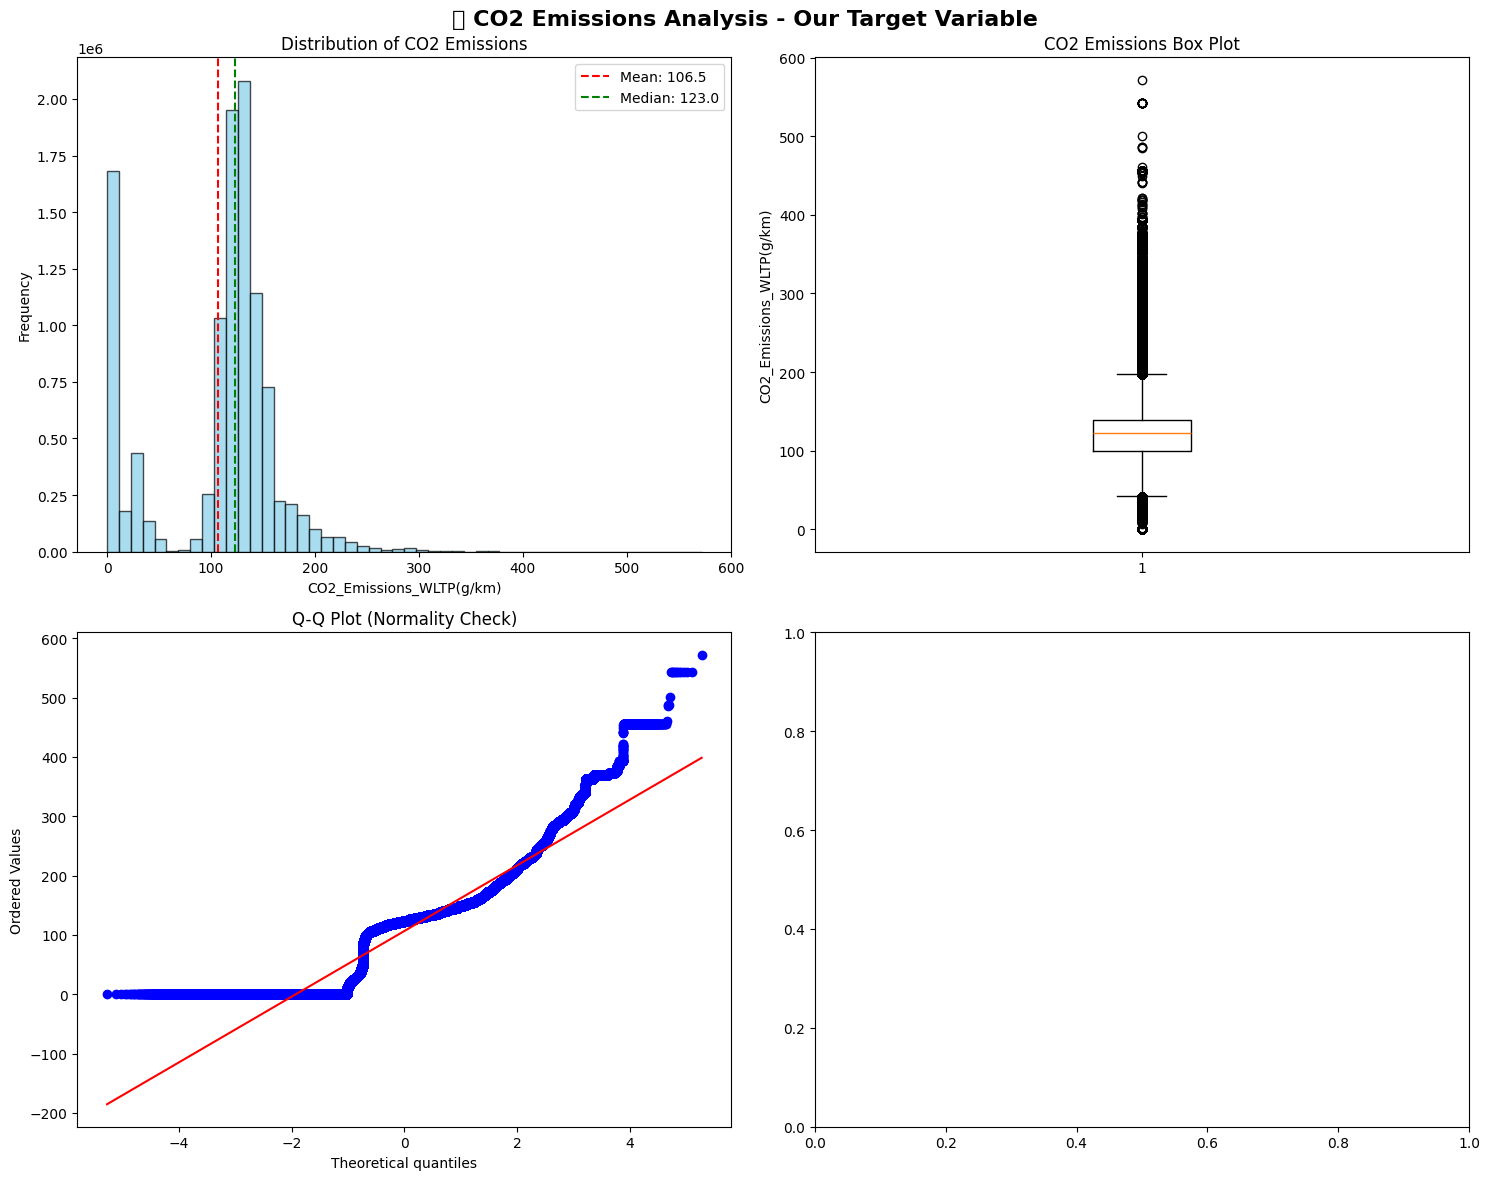

In [26]:
# Create comprehensive CO2 analysis plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🎯 CO2 Emissions Analysis - Our Target Variable', fontsize=16, fontweight='bold')

# Distribution histogram
axes[0,0].hist(df_a['CO2_Emissions_WLTP(g/km)'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].axvline(df_a['CO2_Emissions_WLTP(g/km)'].mean(), color='red', linestyle='--', label=f'Mean: {df_a["CO2_Emissions_WLTP(g/km)"].mean():.1f}')
axes[0,0].axvline(df_a['CO2_Emissions_WLTP(g/km)'].median(), color='green', linestyle='--', label=f'Median: {df_a["CO2_Emissions_WLTP(g/km)"].median():.1f}')
axes[0,0].set_title('Distribution of CO2 Emissions')
axes[0,0].set_xlabel('CO2_Emissions_WLTP(g/km)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Box plot
axes[0,1].boxplot(df_a['CO2_Emissions_WLTP(g/km)'].dropna())
axes[0,1].set_title('CO2 Emissions Box Plot')
axes[0,1].set_ylabel('CO2_Emissions_WLTP(g/km)')

# Q-Q plot for normality
stats.probplot(df_a['CO2_Emissions_WLTP(g/km)'].dropna(), dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot (Normality Check)')



plt.tight_layout()
plt.show()


Filtering for only Combustion motor cars are very crucial as Electronic ones have 0 and close to 0 values

## **Data Reduction**<br> 
- Filtering for "only Combustion" motor cars <br>
- selecting variables that make sense to study combustion <br>
- applying unique values <br> 
- handling variables with high Zero content

### Filtering Petrol and Diesel

In [27]:
# Filtering the DataFrame to include only petrol and diesel vehicles
df_a = df_a[df_a['Fuel_Type'].isin(['petrol', 'diesel'])]

# Displaying the shape of the DataFrame after filtering
df_a.shape

(7914435, 32)

In [28]:
df_a['Fuel_Type'].value_counts()

Fuel_Type
petrol    6092556
diesel    1821879
Name: count, dtype: int64

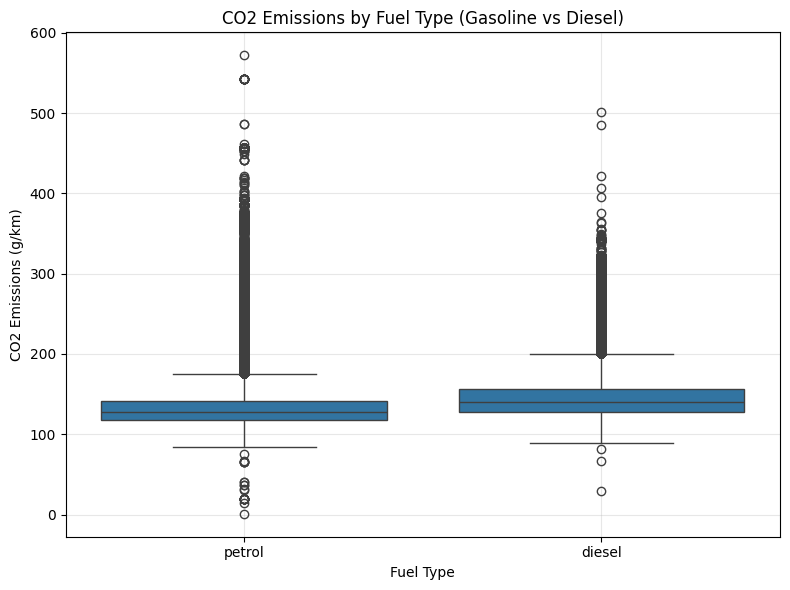

In [29]:
# Create the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Fuel_Type', y='CO2_Emissions_WLTP(g/km)', data=df_a)
plt.title('CO2 Emissions by Fuel Type (Gasoline vs Diesel)')
plt.xlabel('Fuel Type')
plt.ylabel('CO2 Emissions (g/km)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Difference between Petrol and Diesel?

are petrol and diesel significant difference?

In [30]:
from scipy.stats import mannwhitneyu

# Filter data
co2_petrol = df_a[df_a['Fuel_Type'] == 'petrol']['CO2_Emissions_WLTP(g/km)']
co2_diesel = df_a[df_a['Fuel_Type'] == 'diesel']['CO2_Emissions_WLTP(g/km)']

# Perform Mann–Whitney U test
u_stat, p_value = mannwhitneyu(co2_petrol, co2_diesel, alternative='two-sided')

print("Mann–Whitney U Test")
print(f"U statistic = {u_stat}")
print(f"P-value = {p_value:.6f}")

# Interpret
alpha = 0.05
if p_value < alpha:
    print("✅ Statistically significant difference between petrol and diesel CO₂ emissions.")
else:
    print("❌ No statistically significant difference between petrol and diesel CO₂ emissions.")

Mann–Whitney U Test
U statistic = 3586760551499.5
P-value = 0.000000
✅ Statistically significant difference between petrol and diesel CO₂ emissions.


This is important to consider, we should keep this variable, because the CO2 Emissions are considerable different

### Exploring and selecting the rest of the variables

In [31]:
# Null values and their percentage in each column

df_info = pd.DataFrame({
    'Column': df_a.columns,
    'Data Type': df_a.dtypes,
    'Non-Null Count': df_a.count(),
    'Null Count': df_a.isnull().sum(),
    'Null Percentage': (df_a.isnull().sum() / len(df_a) * 100).round(2)
})
print(df_info.to_string(index=False))

                                     Column Data Type  Non-Null Count  Null Count  Null Percentage
                                 Vehicle_ID     int64         7914435           0              0.0
                                    Country    object         7914435           0              0.0
                   Vehicle_Family_id_number    object         7894810       19625              0.2
                       Manufacturer_Pooling    object         7643166      271269              3.4
                          Manufacturer_Name    object         7914435           0              0.0
                      Manufacturer_name_OEM    object         7914435           0              0.0
                       Type_approval_number    object         7901301       13134              0.2
                                       Type    object         7909854        4581              0.1
                                    Variant    object         7901476       12959              0.2
          

<span style="color: orange;">Final Column Decisions for dropping</span> <br>
Vehicle_Family_id_number - the model of the car is already described by other variables <br>
Manufacturer_Pooling - the model of the car is already described by other variables <br>
Manufacturer_Name - the model of the car is already described by other variables <br>
Manufacturer_name_OEM - the model of the car is already described by other variables <br>
Manufacturer_name_MS - the model of the car is already described by other variables <br>
Type_approval_number - the model of the car is already described by other variables <br>
Type - It will be used for filtering <br>
Variant - It will be used for filtering<br>
Version - It will be used for filtering <br>
Make - It will not be used for filtering due to many typos/different way of writing <br>
Commercial_Name - It will not be used for filtering due to many typos/different way of writing <br>
Category_type_approved - not relevant for CO2 <br>
Category_type_registered - not relevant for CO2 <br>
Total_new_registrations - not relevant for CO2 <br>
Mass_in_Running_Order(kg) - stay <br>
WLTP_test_mass - stay <br>
CO2_Emissions_NEDC(g/km) - the whole is zeros <br>
CO2_Emissions_WLTP(g/km) - our target <br>
Wheelbase(mm) - the whole is zeros <br>
Axle_Track_1(mm) - the whole is zeros <br>
Axle_Track_2(mm) - the whole is zeros<br>
Fuel_Type - we should keep it<br>
Fuel_Mode - stay<br>
Engine_Capacity(cm3) - stay<br>
Engine_Power(kW) - stay<br>
Electric_Energy_Consumption(Wh/km) - not relevant for Combustion<br>
Innovative_Technologies - 35% of zeros, delete<br>
Emmission_reduction_through_innovation - 30& of zeros, delete<br>
Emmission_reduction_through_innovation_WLTP - 30% of zeros, delete<br>
Deviation_factor - 100% of zeros, delete<br>
Verification_factor - 100% of zeros, delete<br>
Status - delete not relevant for study<br>
 year - delete not relevant for study<br>
Date of registration - delete, not relevant for study<br>
Fuel consumption - stay<br>
Electric_Charge - not relevant for Combustion<br>
RLFI - Delete, a lot of zeros
Electric range (km) - delete, not relevant for study<br>

In [32]:
columns_to_drop = ['Vehicle_ID','Vehicle_Family_id_number', 'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM', 'Country',
                   'Commercial_Name', 'Type_approval_number', 'Make', 'Category_type_approved', 
                   'Category_type_registered','Total_new_registrations','Electric_Energy_Consumption(Wh/km)','year',
                   'Emmission_reduction_through_innovation_WLTP',
                   'Status','Date of registration','Electric_Charge','RLFI', 'Electric range (km)' ]

df_a = df_a.drop(columns_to_drop, axis=1)

#### what about Fuel mode? what is it behind? <--- FIltering "M"

In [33]:
df_a['Fuel_Mode'].value_counts()

Fuel_Mode
M    5053291
H    2853870
F       7274
Name: count, dtype: int64

This fuel modes are the way they do the tests in the emission tests. We should stick only to onw of those

Fuel_Mode Codes Explained

| Code | Meaning                        | Description                                                                 |
|------|--------------------------------|-----------------------------------------------------------------------------|
| **M** | **Mixed** or **Combined Mode** | This is the standard test mode combining **urban and extra-urban cycles**, or a **weighted average** of several driving phases (used in WLTP or NEDC cycles). |
| **H** | **High** or **Extra-Urban**    | Refers to higher-speed or **extra-urban driving conditions** (e.g., highway). Often used to isolate performance/emissions in faster driving. |
| **F** | **Full Power / Fast / Urban Cold** (less common) | Could refer to a cold start cycle, or a specific **urban test cycle**, but with only 36 entries it's probably a rare, legacy, or test-specific label. |

We should filter only one way to measure CO2 Emissions

In [34]:
#how is the shape before change
df_a.shape

(7914435, 12)

In [35]:
#Filtering Fuel Mode M
df_a = df_a[df_a['Fuel_Mode']== 'M']

In [36]:
#Verifying how much it reduced
df_a.shape

(5053291, 12)

### Looking for Multicolinearities <--- Deleting Fuel Consumption and Mass WLTP

Correlation with CO2 emissions:
CO2_Emissions_WLTP(g/km)                           1.
Fuel_consumption                                   0.95
Engine_Power(kW)                                   0.83
WLTP_test_mass                                     0.79
Mass_in_Running_Order(kg)                          0.79
Engine_Capacity(cm3)                               0.74


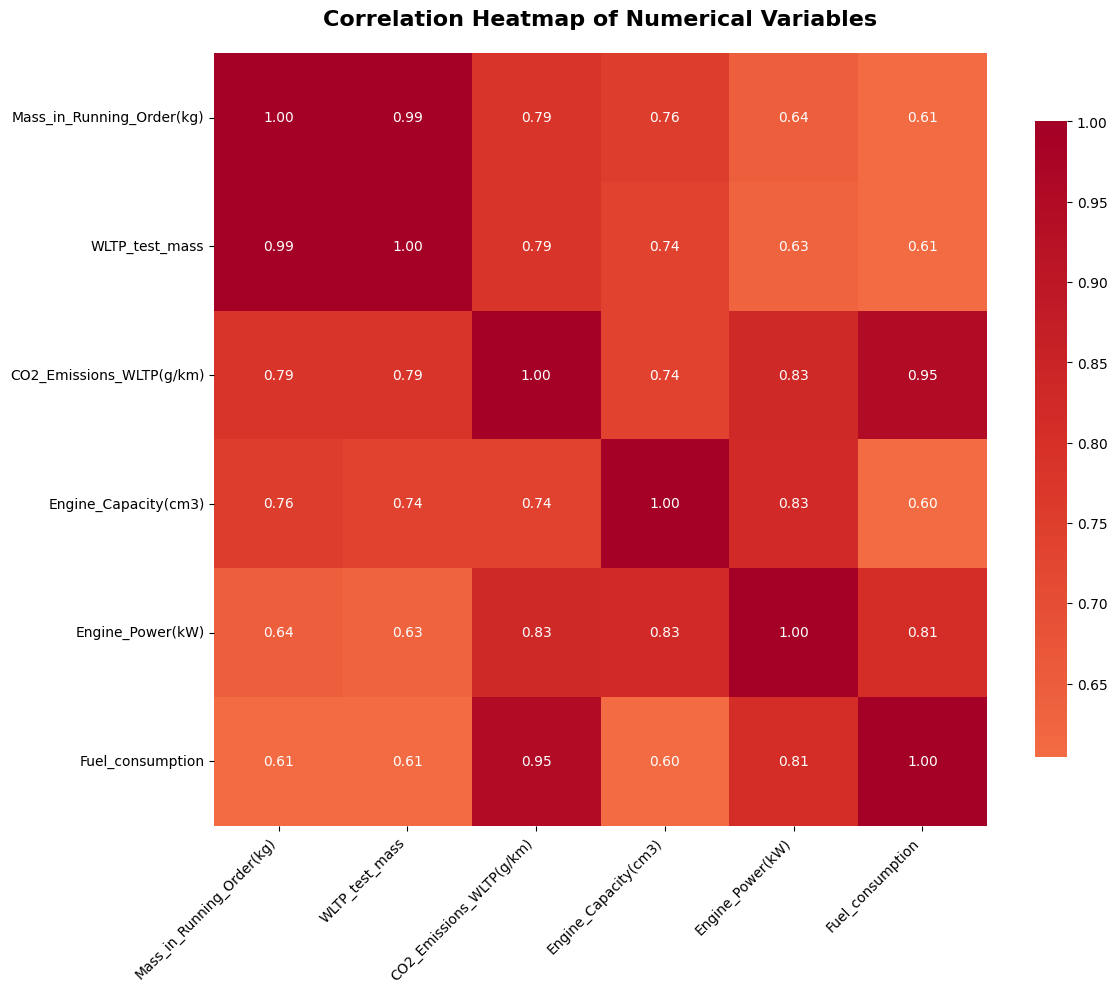

In [37]:
# Correlation analysis with CO2 emissions
# Selecting numerical columns for correlation analysis
numerical_cols = df_a.select_dtypes(include=[np.number]).columns

#display(numerical_cols)

corr_with_co2 = df_a[numerical_cols].corr()['CO2_Emissions_WLTP(g/km)'].sort_values(ascending=False)
print("Correlation with CO2 emissions:")
for var, corr_val in corr_with_co2.items():
    print(f"{var:<50} {np.format_float_positional(corr_val, precision=2)}")


# Create correlation matrix for all numerical columns
correlation_matrix = df_a[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            cmap='RdYlBu_r',      # Color scheme (red-yellow-blue reversed)
            center=0,             # Center colormap at 0
            square=True,          # Make cells square-shaped
            fmt='.2f',            # Format numbers to 2 decimal places
            cbar_kws={'shrink': 0.8})  # Adjust colorbar size

plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Assuming your dataframe is called 'df'
# Select only the numerical features (exclude the target variable CO2(g/km))
features = [
                 'Fuel_consumption',
                 'Engine_Capacity(cm3)',
                 'Engine_Power(kW)',
                 'WLTP_test_mass',
                 'Mass_in_Running_Order(kg)',
]

# Create a subset with only the features
X = df_a[features]

# Handle any missing values if necessary
X = X.dropna()

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Sort by VIF values (descending)
vif_data = vif_data.sort_values('VIF', ascending=False)
print("VIF Values:")
print(vif_data)


VIF Values:
                     Feature    VIF
4  Mass_in_Running_Order(kg) 1745.9
3             WLTP_test_mass 1676.6
0           Fuel_consumption   50.3
1       Engine_Capacity(cm3)   46.1
2           Engine_Power(kW)   23.2


##### Droping WLTP Mass

serious multi-colinearity between Mass_in_Running_Order(kg) and WLTP_test_mass, we'll delete the one with mroe zeros

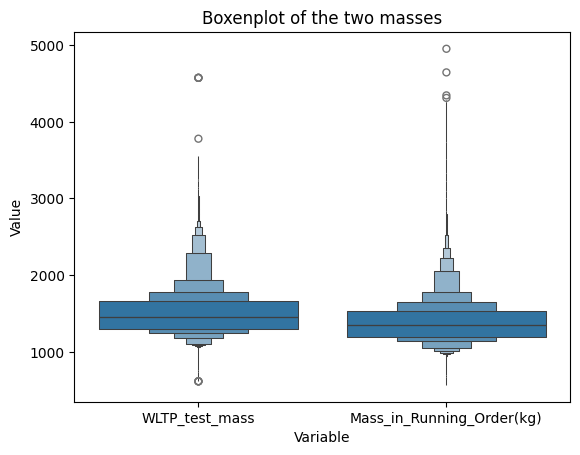

In [39]:

# Pick two numerical columns
cols = ['WLTP_test_mass', 'Mass_in_Running_Order(kg)']

# Melt the data
df_melted = df_a[cols].melt(var_name='Variable', value_name='Value')

# Plot
sns.boxenplot(x='Variable', y='Value', data=df_melted)
plt.title('Boxenplot of the two masses')
plt.show()

In [40]:
#calculating the difference in means
difference_masses = df_a['WLTP_test_mass'].mean() - df_a['Mass_in_Running_Order(kg)'].mean() 

In [41]:
df_a['Mass_in_Running_Order(kg)'] = df_a['Mass_in_Running_Order(kg)'].fillna(
    df_a['WLTP_test_mass'] - difference_masses)

In [42]:
df_info = pd.DataFrame({
    'Column': df_a.columns,
    'Data Type': df_a.dtypes,
    'Non-Null Count': df_a.count(),
    'Null Count': df_a.isnull().sum(),
    'Null Percentage': (df_a.isnull().sum() / len(df_a) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
                     Type    object         5052599         692              0.0
                  Variant    object         5046730        6561              0.1
                  Version    object         5044728        8563              0.2
Mass_in_Running_Order(kg)   float64         5053271          20              0.0
           WLTP_test_mass   float64         5021471       31820              0.6
 CO2_Emissions_WLTP(g/km)   float64         5053291           0              0.0
                Fuel_Type    object         5053291           0              0.0
                Fuel_Mode    object         5053291           0              0.0
     Engine_Capacity(cm3)   float64         5053257          34              0.0
         Engine_Power(kW)   float64         5049384        3907              0.1
  Innovative_Technologies    object         4522860      530431             10.5
         Fuel_consumption   

now we drop the WLTP_test_mass

In [43]:

df_a = df_a.drop('WLTP_test_mass', axis=1)

##### Dropping Fuel Consumption

Fuel_consumption and CO2 are very high correlated (0.97) and also has 20% of missing data, thus we'll drop it

In [44]:
df_a = df_a.drop('Fuel_consumption', axis=1)

In [45]:
df_info = pd.DataFrame({
    'Column': df_a.columns,
    'Data Type': df_a.dtypes,
    'Non-Null Count': df_a.count(),
    'Null Count': df_a.isnull().sum(),
    'Null Percentage': (df_a.isnull().sum() / len(df_a) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
                     Type    object         5052599         692              0.0
                  Variant    object         5046730        6561              0.1
                  Version    object         5044728        8563              0.2
Mass_in_Running_Order(kg)   float64         5053271          20              0.0
 CO2_Emissions_WLTP(g/km)   float64         5053291           0              0.0
                Fuel_Type    object         5053291           0              0.0
                Fuel_Mode    object         5053291           0              0.0
     Engine_Capacity(cm3)   float64         5053257          34              0.0
         Engine_Power(kW)   float64         5049384        3907              0.1
  Innovative_Technologies    object         4522860      530431             10.5


In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Assuming your dataframe is called 'df'
# Select only the numerical features (exclude the target variable CO2(g/km))
features = [
                 'Engine_Capacity(cm3)',
                 'Engine_Power(kW)',
                 'Mass_in_Running_Order(kg)',
]

# Create a subset with only the features
X = df_a[features]

# Handle any missing values if necessary
X = X.dropna()

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Sort by VIF values (descending)
vif_data = vif_data.sort_values('VIF', ascending=False)
print("VIF Values:")
print(vif_data)

VIF Values:
                     Feature  VIF
0       Engine_Capacity(cm3) 40.8
2  Mass_in_Running_Order(kg) 20.9
1           Engine_Power(kW) 15.5


#### Deleting Innovative Technlogies <--- It has high cardinality, 30 percent zeros, very low interpretability and low predictive power

In [47]:
df_a['Innovative_Technologies'].value_counts(normalize=True)

Innovative_Technologies
e2 29 37       0.2
e9 29 37       0.1
e1 29          0.1
e13 29         0.1
e8 29 37       0.1
                ..
e4 32 37       0.0
e24*32/37      0.0
e24 29 e5 29   0.0
e9 29 28       0.0
e13 32 37      0.0
Name: proportion, Length: 112, dtype: float64

Innovative Technologies has a very high cardinality and very low interpretability maybe we should drop it. <br>
lets do a quick test to see its predictive power

In [48]:
"""
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Simple encoding for testing
df_copy = df_a.copy()
df_copy['Innovative_Technologies'] = df_copy['Innovative_Technologies'].astype(str)
df_copy['Innovative_Technologies'] = df_copy['Innovative_Technologies'].astype('category').cat.codes

X = df_copy[['Innovative_Technologies']]
y = df_copy['CO2_Emissions_WLTP(g/km)']  

clf = RandomForestClassifier()
score = cross_val_score(clf, X, y, cv=5).mean()
print("Mean CV Accuracy:", score)
"""

'\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.model_selection import cross_val_score\n\n# Simple encoding for testing\ndf_copy = df_a.copy()\ndf_copy[\'Innovative_Technologies\'] = df_copy[\'Innovative_Technologies\'].astype(str)\ndf_copy[\'Innovative_Technologies\'] = df_copy[\'Innovative_Technologies\'].astype(\'category\').cat.codes\n\nX = df_copy[[\'Innovative_Technologies\']]\ny = df_copy[\'CO2_Emissions_WLTP(g/km)\']  \n\nclf = RandomForestClassifier()\nscore = cross_val_score(clf, X, y, cv=5).mean()\nprint("Mean CV Accuracy:", score)\n'

we run the RandomForest Classifier to evaluate the predictive power of the "Innovative_Technologies" variable. And it was very low. So it is another argument to drop it. We'll proceed to drop it

In [49]:
#dropping Innovative Technologies
df_a = df_a.drop('Innovative_Technologies', axis = 1)

### Target Variable Analysis and its relationship with the other variables

#### Target Variable Analysis: CO2 (g/km) - after filtering

In [60]:
### TARGET VARIABLE ANALYSIS: CO2 (g/km)

display(df_a['CO2_Emissions_WLTP(g/km)'].describe())

count   5053291.0
mean        140.2
std          29.2
min           1.0
25%         123.0
50%         133.0
75%         146.0
max         572.0
Name: CO2_Emissions_WLTP(g/km), dtype: float64

C:\Users\silva\AppData\Local\Temp\ipykernel_17112\3611984606.py:25: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\silva\Documents\GitHub\DataScientest-may25_bds_co2\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


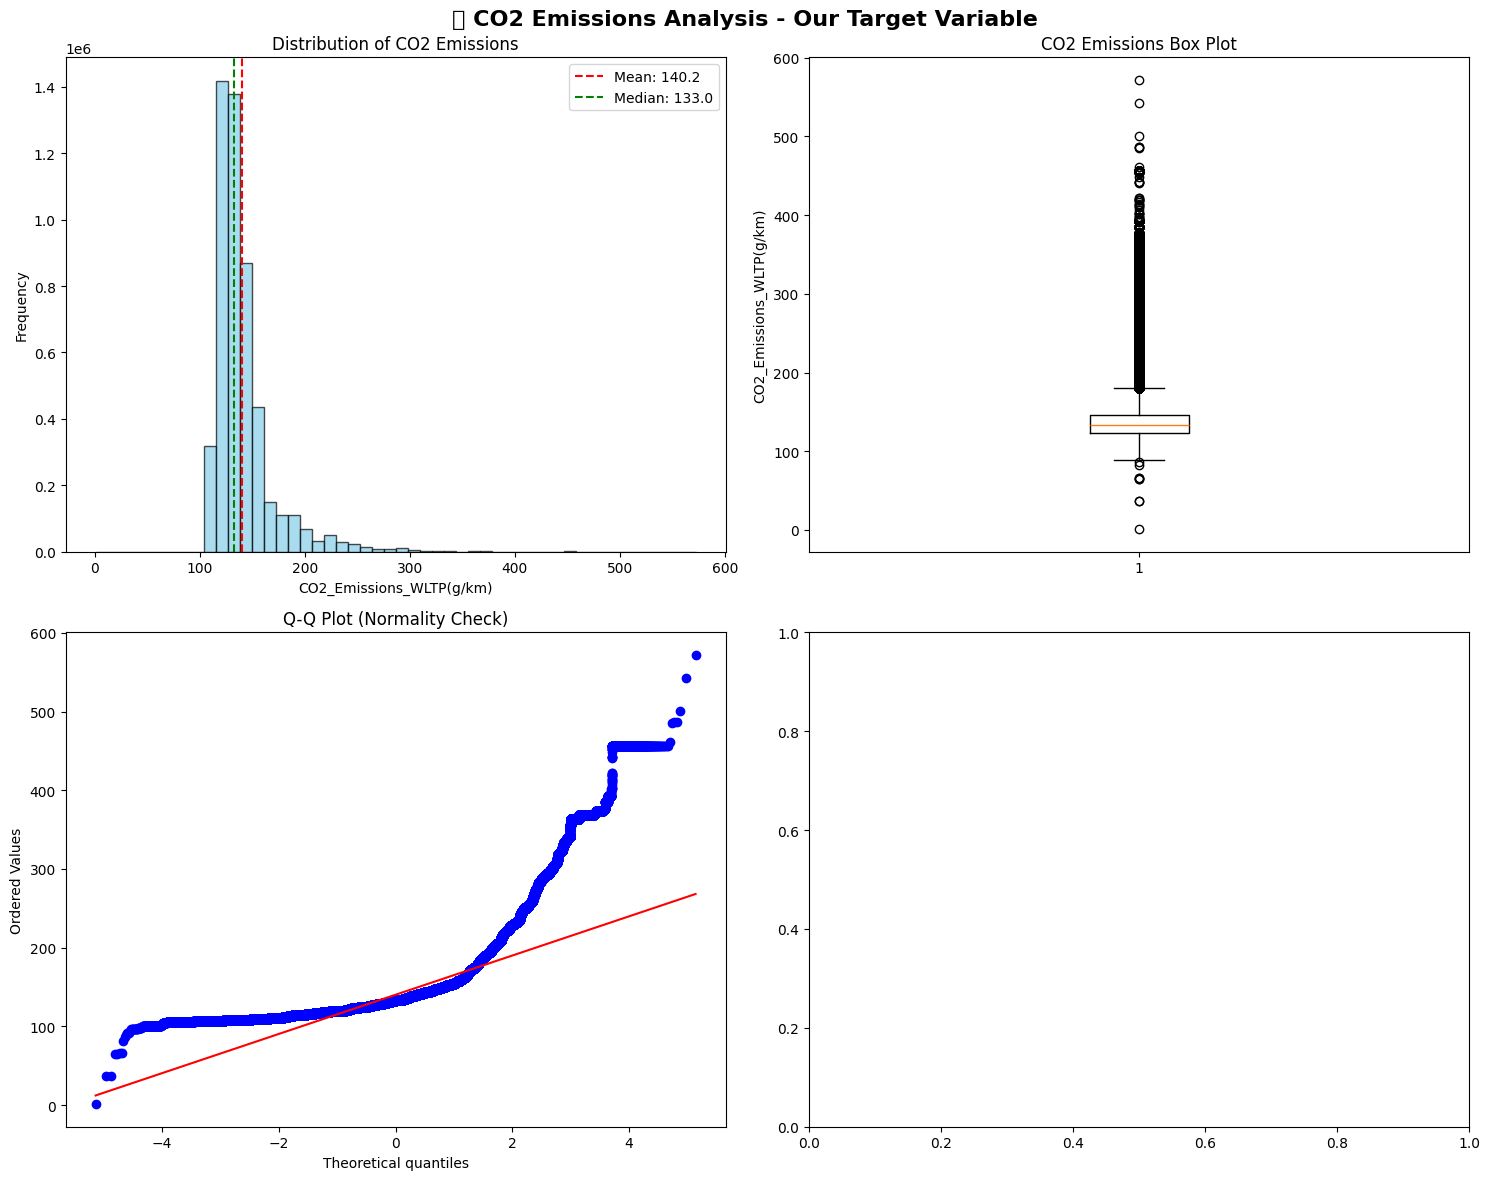

In [61]:
# Create comprehensive CO2 analysis plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🎯 CO2 Emissions Analysis - Our Target Variable', fontsize=16, fontweight='bold')

# Distribution histogram
axes[0,0].hist(df_a['CO2_Emissions_WLTP(g/km)'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].axvline(df_a['CO2_Emissions_WLTP(g/km)'].mean(), color='red', linestyle='--', label=f'Mean: {df_a["CO2_Emissions_WLTP(g/km)"].mean():.1f}')
axes[0,0].axvline(df_a['CO2_Emissions_WLTP(g/km)'].median(), color='green', linestyle='--', label=f'Median: {df_a["CO2_Emissions_WLTP(g/km)"].median():.1f}')
axes[0,0].set_title('Distribution of CO2 Emissions')
axes[0,0].set_xlabel('CO2_Emissions_WLTP(g/km)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Box plot
axes[0,1].boxplot(df_a['CO2_Emissions_WLTP(g/km)'].dropna())
axes[0,1].set_title('CO2 Emissions Box Plot')
axes[0,1].set_ylabel('CO2_Emissions_WLTP(g/km)')

# Q-Q plot for normality
stats.probplot(df_a['CO2_Emissions_WLTP(g/km)'].dropna(), dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot (Normality Check)')



plt.tight_layout()
plt.show()

Q-Q PLOT: The data shows that the Distribution is not Normal, we should consider this for the model steps. We should use a model that does not suppose normal distribution

In [62]:
df_a.shape

(5053291, 9)

#### Does <span style="color:orange"> Engine Capacity </span> has a relationship with CO2 Emissions

- Null Hypothesis (H₀): There is no linear relationship between engine capacity and CO2 emissions.
- Alternative Hypothesis (H₁): There is a significant linear relationship between engine capacity and CO2 emissions.
- Expected: Larger engine capacity should correlate with higher CO2 emissions due to increased fuel consumption.

=== ENGINE CAPACITY AND CO2 EMISSIONS CORRELATION ANALYSIS ===

1. Correlation Analysis:
Pearson Correlation Coefficient: nan
Pearson P-value: nan
Spearman Correlation Coefficient: nan
Spearman P-value: nan

Correlation Strength Interpretation:
Pearson: Very Strong negative linear relationship
Spearman: Very Strong negative monotonic relationship

4. Statistical Significance (α = 0.05):
Pearson: Not statistically significant
Spearman: Not statistically significant

5. Coefficient of Determination (R²): nan
   Interpretation: nan% of variance in CO2 emissions is explained by engine capacity


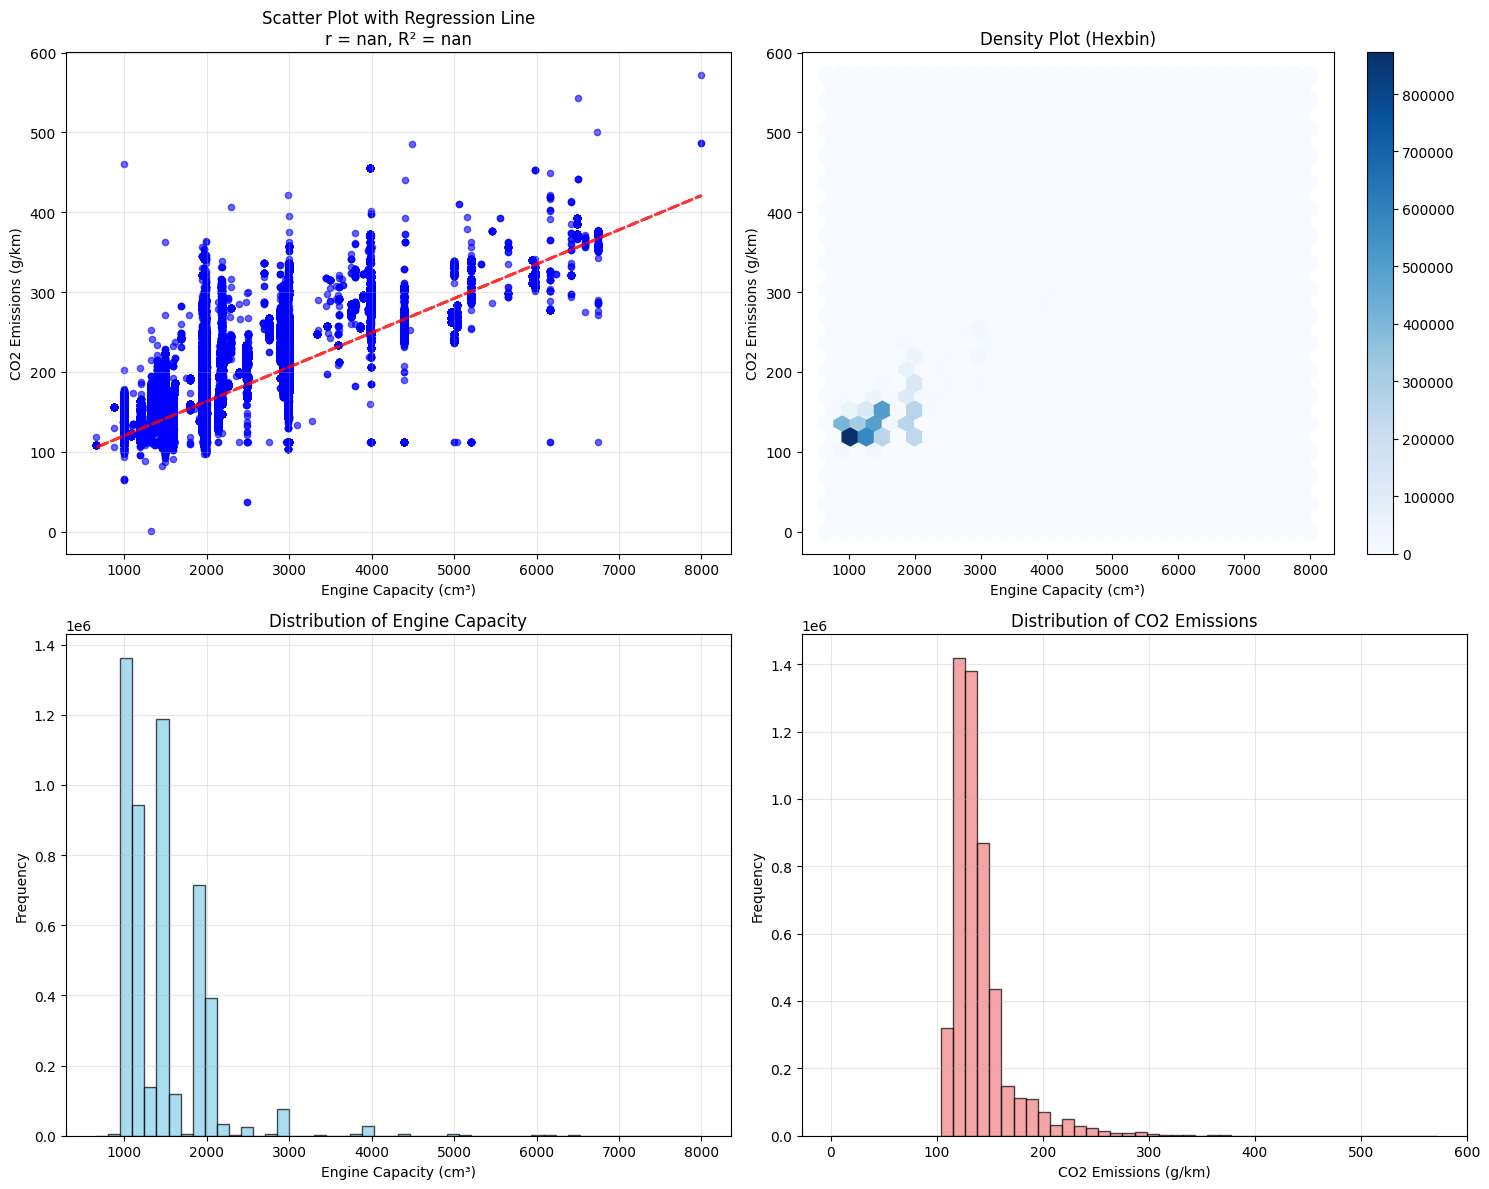


=== CONCLUSION ===
There is NO statistically significant linear relationship between engine capacity and CO2 emissions.
Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.

Note: If Spearman correlation (nan) is much different from Pearson correlation (nan),
this suggests a non-linear monotonic relationship might exist.


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

print("=== ENGINE CAPACITY AND CO2 EMISSIONS CORRELATION ANALYSIS ===")

# 1. Correlation Analysis
print(f"\n1. Correlation Analysis:")

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(df_a['Engine_Capacity(cm3)'], df_a['CO2_Emissions_WLTP(g/km)'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.6f}")
print(f"Pearson P-value: {pearson_p:.6f}")

# Spearman correlation (monotonic relationship)
spearman_corr, spearman_p = spearmanr(df_a['Engine_Capacity(cm3)'], df_a['CO2_Emissions_WLTP(g/km)'])
print(f"Spearman Correlation Coefficient: {spearman_corr:.6f}")
print(f"Spearman P-value: {spearman_p:.6f}")

# Interpretation
print(f"\nCorrelation Strength Interpretation:")
def interpret_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        return "Negligible"
    elif abs_corr < 0.3:
        return "Weak"
    elif abs_corr < 0.5:
        return "Moderate"
    elif abs_corr < 0.7:
        return "Strong"
    else:
        return "Very Strong"

print(f"Pearson: {interpret_correlation(pearson_corr)} {'positive' if pearson_corr > 0 else 'negative'} linear relationship")
print(f"Spearman: {interpret_correlation(spearman_corr)} {'positive' if spearman_corr > 0 else 'negative'} monotonic relationship")

# 4. Statistical Significance
alpha = 0.05
print(f"\n4. Statistical Significance (α = {alpha}):")
print(f"Pearson: {'Statistically significant' if pearson_p < alpha else 'Not statistically significant'}")
print(f"Spearman: {'Statistically significant' if spearman_p < alpha else 'Not statistically significant'}")

# 5. Coefficient of Determination (R²)
r_squared = pearson_corr**2
print(f"\n5. Coefficient of Determination (R²): {r_squared:.6f}")
print(f"   Interpretation: {r_squared*100:.2f}% of variance in CO2 emissions is explained by engine capacity")

# 6. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Drop NaNs before polyfit
df_clean = df_a[['Engine_Capacity(cm3)', 'CO2_Emissions_WLTP(g/km)']].dropna()

# Scatter plot with regression line
axes[0,0].scatter(df_clean['Engine_Capacity(cm3)'], df_clean['CO2_Emissions_WLTP(g/km)'], 
                  alpha=0.6, s=20, color='blue')
# Add regression line
z = np.polyfit(df_clean['Engine_Capacity(cm3)'], df_clean['CO2_Emissions_WLTP(g/km)'], 1)
p = np.poly1d(z)
axes[0,0].plot(df_clean['Engine_Capacity(cm3)'], p(df_clean['Engine_Capacity(cm3)']), 
               "r--", alpha=0.8, linewidth=2)
axes[0,0].set_xlabel('Engine Capacity (cm³)')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].set_title(f'Scatter Plot with Regression Line\nr = {pearson_corr:.4f}, R² = {r_squared:.4f}')
axes[0,0].grid(True, alpha=0.3)

# Hexbin plot for density
hb = axes[0,1].hexbin(df_clean['Engine_Capacity(cm3)'], df_clean['CO2_Emissions_WLTP(g/km)'], 
                      gridsize=30, cmap='Blues')
axes[0,1].set_xlabel('Engine Capacity (cm³)')
axes[0,1].set_ylabel('CO2 Emissions (g/km)')
axes[0,1].set_title('Density Plot (Hexbin)')
plt.colorbar(hb, ax=axes[0,1])

# Distribution plots
axes[1,0].hist(df_clean['Engine_Capacity(cm3)'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,0].set_xlabel('Engine Capacity (cm³)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Engine Capacity')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(df_clean['CO2_Emissions_WLTP(g/km)'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of CO2 Emissions')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



print("\n=== CONCLUSION ===")
if pearson_p < alpha:
    print("There IS a statistically significant linear relationship between engine capacity and CO2 emissions.")
    print(f"The correlation is {interpret_correlation(pearson_corr).lower()} and {'positive' if pearson_corr > 0 else 'negative'}.")
    print(f"Engine capacity explains {r_squared*100:.2f}% of the variance in CO2 emissions.")
    
    if pearson_corr > 0:
        print("As engine capacity increases, CO2 emissions tend to increase.")
    else:
        print("As engine capacity increases, CO2 emissions tend to decrease.")
        
else:
    print("There is NO statistically significant linear relationship between engine capacity and CO2 emissions.")
    print("Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.")

# Check for non-linear relationships
print(f"\nNote: If Spearman correlation ({spearman_corr:.4f}) is much different from Pearson correlation ({pearson_corr:.4f}),")
print("this suggests a non-linear monotonic relationship might exist.")

#### Does <span style="color:orange"> Engine Power </span> have a relationship with CO2 Emissions

- Null Hypothesis (H₀): There is no linear relationship between fuel consumoption and CO2 emissions.
- Alternative Hypothesis (H₁): There is a significant linear relationship between fuel consumoption and CO2 emissions.
- Expected: Larger engine capacity should correlate with higher CO2 emissions due to increased fuel consumption.

=== ENGINE POWER AND CO2 EMISSIONS CORRELATION ANALYSIS ===

1. Correlation Analysis:
Pearson Correlation Coefficient: nan
Pearson P-value: nan
Spearman Correlation Coefficient: nan
Spearman P-value: nan

Correlation Strength Interpretation:
Pearson: Very Strong negative linear relationship
Spearman: Very Strong negative monotonic relationship

4. Statistical Significance (α = 0.05):
Pearson: Not statistically significant
Spearman: Not statistically significant

5. Coefficient of Determination (R²): nan
   Interpretation: nan% of variance in CO2 emissions is explained by engine capacity


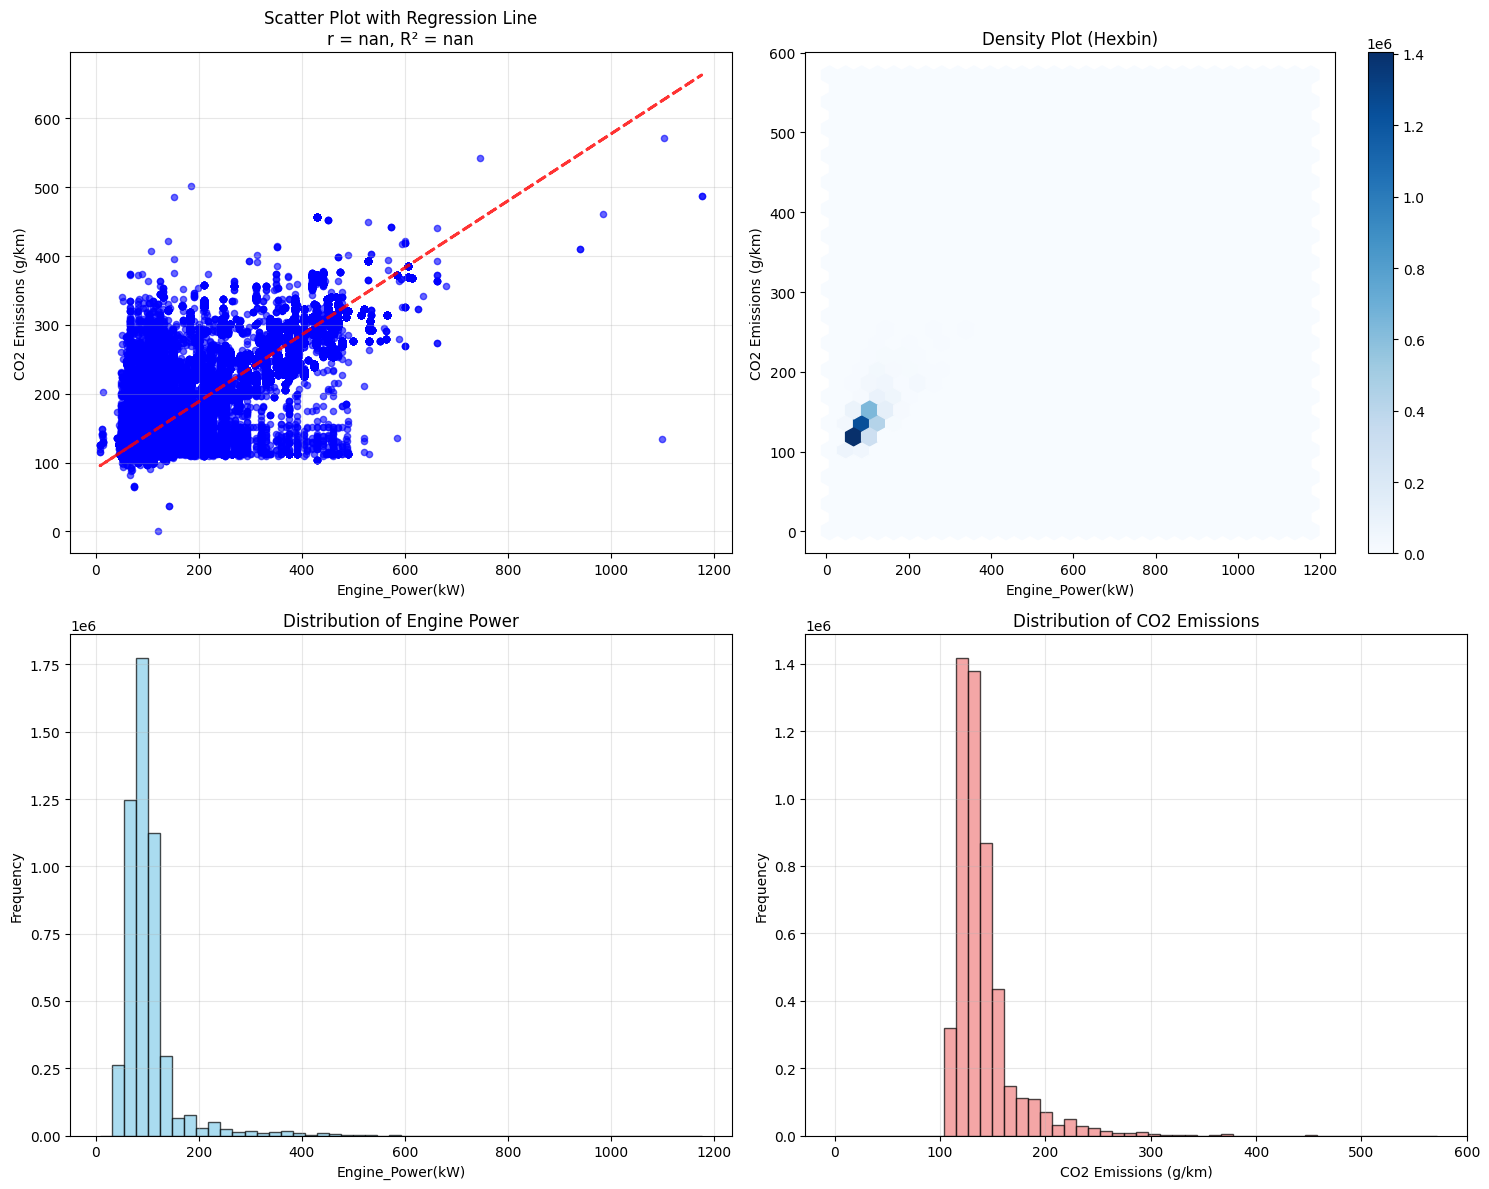


=== CONCLUSION ===
There is NO statistically significant linear relationship between engine capacity and CO2 emissions.
Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.

Note: If Spearman correlation (nan) is much different from Pearson correlation (nan),
this suggests a non-linear monotonic relationship might exist.


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

print("=== ENGINE POWER AND CO2 EMISSIONS CORRELATION ANALYSIS ===")

# 1. Correlation Analysis
print(f"\n1. Correlation Analysis:")

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(df_a['Engine_Power(kW)'], df_a['CO2_Emissions_WLTP(g/km)'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.6f}")
print(f"Pearson P-value: {pearson_p:.6f}")

# Spearman correlation (monotonic relationship)
spearman_corr, spearman_p = spearmanr(df_a['Engine_Power(kW)'], df_a['CO2_Emissions_WLTP(g/km)'])
print(f"Spearman Correlation Coefficient: {spearman_corr:.6f}")
print(f"Spearman P-value: {spearman_p:.6f}")

# Interpretation
print(f"\nCorrelation Strength Interpretation:")
def interpret_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        return "Negligible"
    elif abs_corr < 0.3:
        return "Weak"
    elif abs_corr < 0.5:
        return "Moderate"
    elif abs_corr < 0.7:
        return "Strong"
    else:
        return "Very Strong"

print(f"Pearson: {interpret_correlation(pearson_corr)} {'positive' if pearson_corr > 0 else 'negative'} linear relationship")
print(f"Spearman: {interpret_correlation(spearman_corr)} {'positive' if spearman_corr > 0 else 'negative'} monotonic relationship")

# 4. Statistical Significance
alpha = 0.05
print(f"\n4. Statistical Significance (α = {alpha}):")
print(f"Pearson: {'Statistically significant' if pearson_p < alpha else 'Not statistically significant'}")
print(f"Spearman: {'Statistically significant' if spearman_p < alpha else 'Not statistically significant'}")

# 5. Coefficient of Determination (R²)
r_squared = pearson_corr**2
print(f"\n5. Coefficient of Determination (R²): {r_squared:.6f}")
print(f"   Interpretation: {r_squared*100:.2f}% of variance in CO2 emissions is explained by engine capacity")

# 6. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Drop NaNs before polyfit
df_clean = df_a[['Engine_Power(kW)', 'CO2_Emissions_WLTP(g/km)']].dropna()



# Scatter plot with regression line
axes[0,0].scatter(df_clean['Engine_Power(kW)'], df_clean['CO2_Emissions_WLTP(g/km)'], 
                  alpha=0.6, s=20, color='blue')
# Add regression line
z = np.polyfit(df_clean['Engine_Power(kW)'], df_clean['CO2_Emissions_WLTP(g/km)'], 1)
p = np.poly1d(z)
axes[0,0].plot(df_clean['Engine_Power(kW)'], p(df_clean['Engine_Power(kW)']), 
               "r--", alpha=0.8, linewidth=2)
axes[0,0].set_xlabel('Engine_Power(kW)')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].set_title(f'Scatter Plot with Regression Line\nr = {pearson_corr:.4f}, R² = {r_squared:.4f}')
axes[0,0].grid(True, alpha=0.3)

# Hexbin plot for density
hb = axes[0,1].hexbin(df_clean['Engine_Power(kW)'], df_clean['CO2_Emissions_WLTP(g/km)'], 
                      gridsize=30, cmap='Blues')
axes[0,1].set_xlabel('Engine_Power(kW)')
axes[0,1].set_ylabel('CO2 Emissions (g/km)')
axes[0,1].set_title('Density Plot (Hexbin)')
plt.colorbar(hb, ax=axes[0,1])

# Distribution plots
axes[1,0].hist(df_clean['Engine_Power(kW)'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,0].set_xlabel('Engine_Power(kW)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Engine Power')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(df_clean['CO2_Emissions_WLTP(g/km)'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of CO2 Emissions')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



print("\n=== CONCLUSION ===")
if pearson_p < alpha:
    print("There IS a statistically significant linear relationship between engine capacity and CO2 emissions.")
    print(f"The correlation is {interpret_correlation(pearson_corr).lower()} and {'positive' if pearson_corr > 0 else 'negative'}.")
    print(f"Engine capacity explains {r_squared*100:.2f}% of the variance in CO2 emissions.")
    
    if pearson_corr > 0:
        print("As engine capacity increases, CO2 emissions tend to increase.")
    else:
        print("As engine capacity increases, CO2 emissions tend to decrease.")
        
else:
    print("There is NO statistically significant linear relationship between engine capacity and CO2 emissions.")
    print("Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.")

# Check for non-linear relationships
print(f"\nNote: If Spearman correlation ({spearman_corr:.4f}) is much different from Pearson correlation ({pearson_corr:.4f}),")
print("this suggests a non-linear monotonic relationship might exist.")

#### Does <span style="color:orange"> Mass </span> have a relationship with CO2 Emissions

- Null Hypothesis (H₀): There is no linear relationship between Mass and CO2 emissions.
- Alternative Hypothesis (H₁): There is a significant linear relationship between Mass and CO2 emissions.
- Expected: Larger engine capacity should correlate with higher CO2 emissions due to increased Mass.

=== MASS AND CO2 EMISSIONS CORRELATION ANALYSIS ===

1. Correlation Analysis:
Pearson Correlation Coefficient: nan
Pearson P-value: nan
Spearman Correlation Coefficient: nan
Spearman P-value: nan

Correlation Strength Interpretation:
Pearson: Very Strong negative linear relationship
Spearman: Very Strong negative monotonic relationship

4. Statistical Significance (α = 0.05):
Pearson: Not statistically significant
Spearman: Not statistically significant

5. Coefficient of Determination (R²): nan
   Interpretation: nan% of variance in CO2 emissions is explained by mass


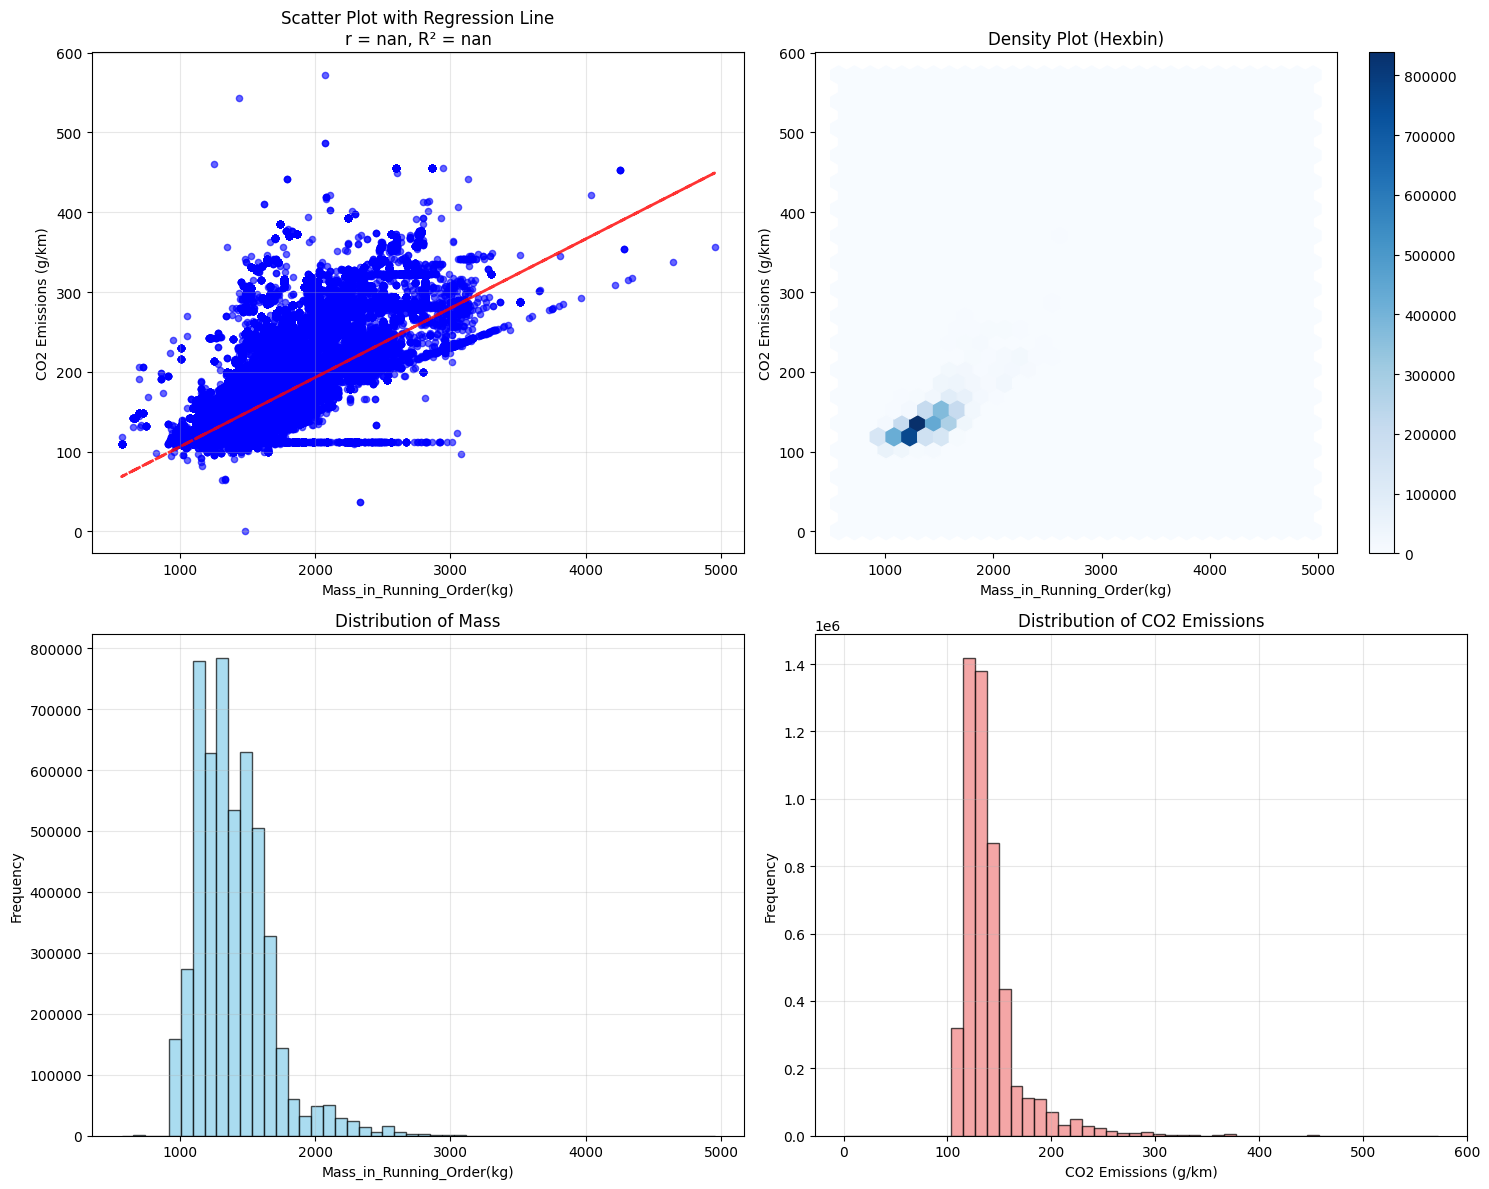


=== CONCLUSION ===
There is NO statistically significant linear relationship between engine capacity and CO2 emissions.
Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.

Note: If Spearman correlation (nan) is much different from Pearson correlation (nan),
this suggests a non-linear monotonic relationship might exist.


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

print("=== MASS AND CO2 EMISSIONS CORRELATION ANALYSIS ===")

# 1. Correlation Analysis
print(f"\n1. Correlation Analysis:")

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(df_a['Mass_in_Running_Order(kg)'], df_a['CO2_Emissions_WLTP(g/km)'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.6f}")
print(f"Pearson P-value: {pearson_p:.6f}")

# Spearman correlation (monotonic relationship)
spearman_corr, spearman_p = spearmanr(df_a['Mass_in_Running_Order(kg)'], df_a['CO2_Emissions_WLTP(g/km)'])
print(f"Spearman Correlation Coefficient: {spearman_corr:.6f}")
print(f"Spearman P-value: {spearman_p:.6f}")

# Interpretation
print(f"\nCorrelation Strength Interpretation:")
def interpret_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        return "Negligible"
    elif abs_corr < 0.3:
        return "Weak"
    elif abs_corr < 0.5:
        return "Moderate"
    elif abs_corr < 0.7:
        return "Strong"
    else:
        return "Very Strong"

print(f"Pearson: {interpret_correlation(pearson_corr)} {'positive' if pearson_corr > 0 else 'negative'} linear relationship")
print(f"Spearman: {interpret_correlation(spearman_corr)} {'positive' if spearman_corr > 0 else 'negative'} monotonic relationship")

# 4. Statistical Significance
alpha = 0.05
print(f"\n4. Statistical Significance (α = {alpha}):")
print(f"Pearson: {'Statistically significant' if pearson_p < alpha else 'Not statistically significant'}")
print(f"Spearman: {'Statistically significant' if spearman_p < alpha else 'Not statistically significant'}")

# 5. Coefficient of Determination (R²)
r_squared = pearson_corr**2
print(f"\n5. Coefficient of Determination (R²): {r_squared:.6f}")
print(f"   Interpretation: {r_squared*100:.2f}% of variance in CO2 emissions is explained by mass")

# 6. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))


# Drop NaNs before polyfit
df_clean = df_a[['Mass_in_Running_Order(kg)', 'CO2_Emissions_WLTP(g/km)']].dropna()



# Scatter plot with regression line
axes[0,0].scatter(df_clean['Mass_in_Running_Order(kg)'], df_clean['CO2_Emissions_WLTP(g/km)'], 
                  alpha=0.6, s=20, color='blue')
# Add regression line
z = np.polyfit(df_clean['Mass_in_Running_Order(kg)'], df_clean['CO2_Emissions_WLTP(g/km)'], 1)
p = np.poly1d(z)
axes[0,0].plot(df_clean['Mass_in_Running_Order(kg)'], p(df_clean['Mass_in_Running_Order(kg)']), 
               "r--", alpha=0.8, linewidth=2)
axes[0,0].set_xlabel('Mass_in_Running_Order(kg)')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].set_title(f'Scatter Plot with Regression Line\nr = {pearson_corr:.4f}, R² = {r_squared:.4f}')
axes[0,0].grid(True, alpha=0.3)

# Hexbin plot for density
hb = axes[0,1].hexbin(df_clean['Mass_in_Running_Order(kg)'], df_clean['CO2_Emissions_WLTP(g/km)'], 
                      gridsize=30, cmap='Blues')
axes[0,1].set_xlabel('Mass_in_Running_Order(kg)')
axes[0,1].set_ylabel('CO2 Emissions (g/km)')
axes[0,1].set_title('Density Plot (Hexbin)')
plt.colorbar(hb, ax=axes[0,1])

# Distribution plots
axes[1,0].hist(df_a['Mass_in_Running_Order(kg)'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,0].set_xlabel('Mass_in_Running_Order(kg)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Mass')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(df_a['CO2_Emissions_WLTP(g/km)'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of CO2 Emissions')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



print("\n=== CONCLUSION ===")
if pearson_p < alpha:
    print("There IS a statistically significant linear relationship between engine capacity and CO2 emissions.")
    print(f"The correlation is {interpret_correlation(pearson_corr).lower()} and {'positive' if pearson_corr > 0 else 'negative'}.")
    print(f"Engine capacity explains {r_squared*100:.2f}% of the variance in CO2 emissions.")
    
    if pearson_corr > 0:
        print("As engine capacity increases, CO2 emissions tend to increase.")
    else:
        print("As engine capacity increases, CO2 emissions tend to decrease.")
        
else:
    print("There is NO statistically significant linear relationship between engine capacity and CO2 emissions.")
    print("Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.")

# Check for non-linear relationships
print(f"\nNote: If Spearman correlation ({spearman_corr:.4f}) is much different from Pearson correlation ({pearson_corr:.4f}),")
print("this suggests a non-linear monotonic relationship might exist.")

### Applying Unique Values to find only unique auto models

Now that we have seen those variables that are important for us we can explore how to see only unique values of cars.

To do this we are going to explore how are some of this variables when we grouped by Version, Variant and Type

In [66]:
df_a.columns

Index(['Type', 'Variant', 'Version', 'Mass_in_Running_Order(kg)',
       'CO2_Emissions_WLTP(g/km)', 'Fuel_Type', 'Fuel_Mode',
       'Engine_Capacity(cm3)', 'Engine_Power(kW)'],
      dtype='object')

In [ ]:
#grouping and aggregating for the Variables of Interest
df_grouped = df_a.groupby(['Version', 'Variant', 'Type']).agg({
    'Engine_Capacity(cm3)': [np.mean, np.std, 'count'],
    'Mass_in_Running_Order(kg)': [np.mean, np.std, 'count'],
    'CO2_Emissions_WLTP(g/km)':[np.mean, np.std, 'count'],
    'Engine_Power(kW)': [np.mean, np.std, 'count']
})



C:\Users\silva\AppData\Local\Temp\ipykernel_17112\320374170.py:2: FutureWarning: The provided callable <function mean at 0x000001FC5DFF74C0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_grouped = df_a.groupby(['Version', 'Variant', 'Type']).agg({
C:\Users\silva\AppData\Local\Temp\ipykernel_17112\320374170.py:2: FutureWarning: The provided callable <function std at 0x000001FC5DFF7600> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  df_grouped = df_a.groupby(['Version', 'Variant', 'Type']).agg({
C:\Users\silva\AppData\Local\Temp\ipykernel_17112\320374170.py:2: FutureWarning: The provided callable <function mean at 0x000001FC5DFF74C0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used

In [68]:
df_grouped.sort_values(('CO2_Emissions_WLTP(g/km)','std'), ascending=False)

Engine_Capacity(cm3)            \
                                                               mean std count   
Version                    Variant  Type                                        
1AACADDD                   F2       724                      5204.0 0.0    31   
5K                         7214LL   ALPINA G12               4395.0 0.0     4   
AAAAAAAAAAA                BAAA     636                      3996.0 0.0    11   
IAA5090A                   41EU     G5X                      2998.0 0.0     2   
AABABBACAAA                BCAA     636                      3996.0 0.0    18   
...                                                             ...  ..   ...   
ZWK7VF0                    ZWK7     Z                        1969.0 NaN     1   
ZWK7VF0?                   ZWK7     Z                        1969.0 NaN     1   
ZYX11L                     ZYX1     AX1T                     1798.0 NaN     1   
ZYX11L-AHXNBW(1K)          ZYX11(H) AX1T(EU M)               1798.0 NaN     1   
¸FD7FD7CK001031B18S54BIAEM ADTPAF1  F2                       1968.0 NaN     1   

                                               Mass_in_Running_Order(kg)      \
                                                                    mean std   
Version                    Variant  Type                                       
1AACADDD                   F2       724                           1607.0 0.0   
5K                         7214LL   ALPINA G12                    2180.0 0.0   
AAAAAAAAAAA                BAAA     636                           2272.0 0.0   
IAA5090A                   41EU     G5X                           2495.0 0.0   
AABABBACAAA                BCAA     636                           2272.0 0.0   
...                                                                  ...  ..   
ZWK7VF0                    ZWK7     Z                             1734.0 NaN   
ZWK7VF0?                   ZWK7     Z                             1734.0 NaN   
ZYX11L                     ZYX1     AX1T                          1495.0 NaN   
ZYX11L-AHXNBW(1K)          ZYX11(H) AX1T(EU M)                    1495.0 NaN   
¸FD7FD7CK001031B18S54BIAEM ADTPAF1  F2                            1780.0 NaN   

                                                     CO2_Emissions_WLTP(g/km)  \
                                               count                     mean   
Version                    Variant  Type                                        
1AACADDD                   F2       724           31                    272.7   
5K                         7214LL   ALPINA G12     4                    188.0   
AAAAAAAAAAA                BAAA     636           11                    283.3   
IAA5090A                   41EU     G5X            2                    161.5   
AABABBACAAA                BCAA     636           18                    296.9   
...                                              ...                      ...   
ZWK7VF0                    ZWK7     Z              1                    155.0   
ZWK7VF0?                   ZWK7     Z              1                    155.0   
ZYX11L                     ZYX1     AX1T           1                    110.0   
ZYX11L-AHXNBW(1K)          ZYX11(H) AX1T(EU M)     1                    110.0   
¸FD7FD7CK001031B18S54BIAEM ADTPAF1  F2             1                    147.0   

                                                          Engine_Power(kW)  \
                                                std count             mean   
Version                    Variant  Type                                     
1AACADDD                   F2       724        97.3    31            458.4   
5K                         7214LL   ALPINA G12 87.8     4            447.0   
AAAAAAAAAAA                BAAA     636        85.2    11            438.3   
IAA5090A                   41EU     G5X        70.0     2            230.0   
AABABBACAAA                BCAA     636        67.3    18            414.4   
...                             

In [69]:
std = df_grouped.iloc[0][('CO2_Emissions_WLTP(g/km)', 'std')]
mean = df_grouped.iloc[0][('CO2_Emissions_WLTP(g/km)', 'mean')]

cv = (std / mean) * 100
print(f"Coefficient of Variation of highest deviation standard for CO2 Emissions: {cv:.2f}%")

Coefficient of Variation of highest deviation standard for CO2 Emissions: 5.95%


In [70]:
std = df_grouped.iloc[0][('Mass_in_Running_Order(kg)', 'std')]
mean = df_grouped.iloc[0][('Mass_in_Running_Order(kg)', 'mean')]

cv = (std / mean) * 100
print(f"Coefficient of Variation of highest deviation standard for Mass: {cv:.2f}%")

Coefficient of Variation of highest deviation standard for Mass: 2.80%


In [71]:
std = df_grouped.iloc[0][('Engine_Power(kW)', 'std')]
mean = df_grouped.iloc[0][('Engine_Power(kW)', 'mean')]

cv = (std / mean) * 100
print(f"Coefficient of Variation of highest deviation standard for Engine Power: {cv:.2f}%")

Coefficient of Variation of highest deviation standard for Engine Power: 0.00%


In [72]:
std = df_grouped.iloc[0][('Engine_Capacity(cm3)', 'std')]
mean = df_grouped.iloc[0][('Engine_Capacity(cm3)', 'mean')]

cv = (std / mean) * 100
print(f"Coefficient of Variation of highest deviation standard for Engine Capacity: {cv:.2f}%")

'Engine_Capacity(cm3)'

Coefficient of Variation of highest deviation standard for Engine Capacity: 0.00%


'Engine_Capacity(cm3)'

In [73]:
df_unique = df_a.drop_duplicates(subset=['Version', 'Variant', 'Type','CO2_Emissions_WLTP(g/km)','Mass_in_Running_Order(kg)','Fuel_Mode','Fuel_Type'])

In [74]:
df_a.shape

(5053291, 9)

In [75]:
df_unique.shape

(75617, 9)

In [76]:
df_unique.head(15)


,Type,Variant,Version,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
2,GB,SDLACF1,FM5FM5DF008RT11B174BIAEM10B0,1175.0,129.0,petrol,M,999.0,70.0
3,PJ,ABDSGDX0,NFM5FM5DF0104BI3N1A1A,1122.0,117.0,petrol,M,999.0,59.0
6,3C,ACDTSBX0,FD7FD7GC004SONV4BIVR21AAMI,1588.0,126.0,diesel,M,1968.0,110.0
7,KL,SFDTTCX0,FD7SFD7GC0024BIVL1BAD16A8T,1516.0,124.0,diesel,M,1968.0,110.0
10,NX,ACDPCAX0,NFM6FM6C90134BIVL4N1A1A,1349.0,126.0,petrol,M,1498.0,110.0
11,YB,C5P51,D71DZ1,1230.0,125.0,petrol,M,998.0,74.0
12,F2B,OXH7T2,FZAA170A,1555.0,162.0,petrol,M,1332.0,120.0
14,DEH,ZTDA1NX,5ZGACNAY8BS,1384.0,110.0,diesel,M,1499.0,88.0
18,DJF,RES,MD6UA4HM7000,1280.0,129.0,petrol,M,999.0,81.0
20,KJ,XDXDB,FD7SFD7CW0064BI3A1AAEA8H,1268.0,130.0,petrol,M,1498.0,110.0


### Handling Zeros


still some NA in Mass_in_Running_Order(kg), lets drop na values

In [77]:
df_unique=  df_unique.dropna(subset=['Mass_in_Running_Order(kg)'])

In [78]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
                     Type    object           75269         331              0.4
                  Variant    object           73510        2090              2.8
                  Version    object           72956        2644              3.5
Mass_in_Running_Order(kg)   float64           75600           0              0.0
 CO2_Emissions_WLTP(g/km)   float64           75600           0              0.0
                Fuel_Type    object           75600           0              0.0
                Fuel_Mode    object           75600           0              0.0
     Engine_Capacity(cm3)   float64           75576          24              0.0
         Engine_Power(kW)   float64           75533          67              0.1


In [79]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
                     Type    object           75269         331              0.4
                  Variant    object           73510        2090              2.8
                  Version    object           72956        2644              3.5
Mass_in_Running_Order(kg)   float64           75600           0              0.0
 CO2_Emissions_WLTP(g/km)   float64           75600           0              0.0
                Fuel_Type    object           75600           0              0.0
                Fuel_Mode    object           75600           0              0.0
     Engine_Capacity(cm3)   float64           75576          24              0.0
         Engine_Power(kW)   float64           75533          67              0.1


In [80]:
df_unique=  df_unique.dropna(subset=['Engine_Capacity(cm3)','Engine_Power(kW)'])

In [81]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
                     Type    object           75201         331              0.4
                  Variant    object           73468        2064              2.7
                  Version    object           72914        2618              3.5
Mass_in_Running_Order(kg)   float64           75532           0              0.0
 CO2_Emissions_WLTP(g/km)   float64           75532           0              0.0
                Fuel_Type    object           75532           0              0.0
                Fuel_Mode    object           75532           0              0.0
     Engine_Capacity(cm3)   float64           75532           0              0.0
         Engine_Power(kW)   float64           75532           0              0.0


#

## Handling Outliers

### For CO2 <--- Deleting lower bound

In [1]:
Q1 = df_unique['CO2_Emissions_WLTP(g/km)'].quantile(0.25)
Q3 = df_unique['CO2_Emissions_WLTP(g/km)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_unique[
    (df_unique['CO2_Emissions_WLTP(g/km)'] < lower_bound) |
    (df_unique['CO2_Emissions_WLTP(g/km)'] > upper_bound)
]

print(f"Number of outliers (IQR method): {len(outliers_iqr)}")

NameError: name 'df_unique' is not defined

In [83]:
outliers_iqr

,Type,Variant,Version,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
132,F56XM,JU01,IAW5E0BA,2410.0,306.0,petrol,M,4395.0,460.0
623,R1SLAMG,S48VTB,TZAM040A,1970.0,299.0,petrol,M,3982.0,430.0
1035,9YA,EI22,1205310,2220.0,297.0,petrol,M,3996.0,338.0
1443,GM,1B4C,B32A5BN,2815.0,292.0,diesel,M,2993.0,183.0
1570,982G,CH12,42,1490.0,299.0,petrol,M,3996.0,368.0
...,...,...,...,...,...,...,...,...,...
10718548,636,NaN,NaN,2326.0,320.0,petrol,M,3996.0,490.0
10721374,636,NaN,NaN,2394.0,320.0,petrol,M,3996.0,490.0
10723565,DF,NaN,NaN,3058.0,407.0,diesel,M,2299.0,107.0
10723732,4V,NaN,NaN,2589.0,294.0,petrol,M,3996.0,404.0


In [84]:
df_unique[df_unique['CO2_Emissions_WLTP(g/km)'] < lower_bound]

,Type,Variant,Version,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
342101,F2B,OHH7T2,FZAA150C,1485.0,1.0,petrol,M,1332.0,120.0
2475457,KL01,2,4BC,2333.0,37.0,petrol,M,2488.0,141.0


We'll delete this two

In [85]:
df_unique = df_unique[~(df_unique['CO2_Emissions_WLTP(g/km)'] < lower_bound)]

### for Engine Capacity <--- Nothing to delete

In [86]:
Q1 = df_unique['Engine_Capacity(cm3)'].quantile(0.25)
Q3 = df_unique['Engine_Capacity(cm3)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_unique[
    (df_unique['Engine_Capacity(cm3)'] < lower_bound) |
    (df_unique['Engine_Capacity(cm3)'] > upper_bound)
]

print(f"Number of outliers (IQR method): {len(outliers_iqr)}")

Number of outliers (IQR method): 6030


In [87]:
df_unique[df_unique['Engine_Capacity(cm3)'] < lower_bound]

,Type,Variant,Version,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
67407,SEVENS3,ZA,5,570.0,109.0,petrol,M,658.0,63.0
2242900,SEVENS3,ZA,5,570.0,119.0,petrol,M,658.0,63.0
3486192,SEVEN S3,ZA,5,570.0,109.0,petrol,M,658.0,63.0
9385547,SEVEN S3,NaN,NaN,570.0,109.0,petrol,M,658.0,63.0
9934683,SEVEN,NaN,NaN,570.0,109.0,petrol,M,658.0,63.0


In [88]:
df_unique[df_unique['Engine_Capacity(cm3)'] < upper_bound]

,Type,Variant,Version,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
2,GB,SDLACF1,FM5FM5DF008RT11B174BIAEM10B0,1175.0,129.0,petrol,M,999.0,70.0
3,PJ,ABDSGDX0,NFM5FM5DF0104BI3N1A1A,1122.0,117.0,petrol,M,999.0,59.0
6,3C,ACDTSBX0,FD7FD7GC004SONV4BIVR21AAMI,1588.0,126.0,diesel,M,1968.0,110.0
7,KL,SFDTTCX0,FD7SFD7GC0024BIVL1BAD16A8T,1516.0,124.0,diesel,M,1968.0,110.0
10,NX,ACDPCAX0,NFM6FM6C90134BIVL4N1A1A,1349.0,126.0,petrol,M,1498.0,110.0
...,...,...,...,...,...,...,...,...,...
10728513,639/2,MAU4L310NXX,2GJVDX27BEXX,2247.0,198.0,diesel,M,1950.0,120.0
10731818,RFK,RPA,MBBA941F1000,1600.0,155.0,petrol,M,1332.0,96.0
10731910,FAD,P0FA1ECX,W9FGAHABBAT6AB,2398.0,237.0,diesel,M,1995.0,110.0
10731924,F,B,YHZL-F21500,1424.0,116.0,diesel,M,1499.0,96.0


<Axes: ylabel='Engine_Capacity(cm3)'>

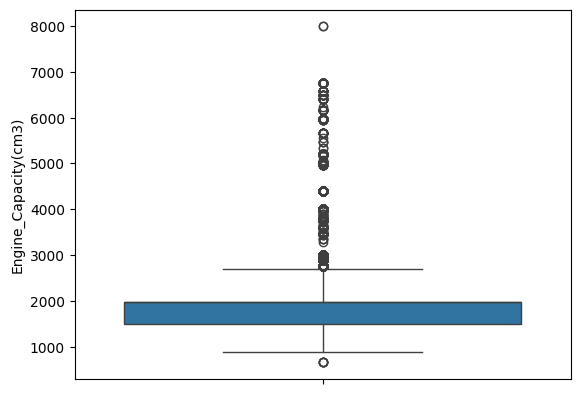

In [89]:
sns.boxplot(df_unique['Engine_Capacity(cm3)'])

Everything seems to be alright

### for Engine Power <--- Nothing to delete

In [90]:
Q1 = df_unique['Engine_Power(kW)'].quantile(0.25)
Q3 = df_unique['Engine_Power(kW)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_unique[
    (df_unique['Engine_Power(kW)'] < lower_bound) |
    (df_unique['Engine_Power(kW)'] > upper_bound)
]

print(f"Number of outliers (IQR method): {len(outliers_iqr)}")

Number of outliers (IQR method): 6429


In [91]:
df_unique[df_unique['Engine_Power(kW)'] < lower_bound]

,Type,Variant,Version,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)


In [92]:
df_unique[df_unique['Engine_Power(kW)'] > upper_bound]

,Type,Variant,Version,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
112,KM,CXDNFBX1,AD7CAD7GC0064BI1CAC,1616.0,193.0,petrol,M,1984.0,228.0
118,R1ES,U223T1,CZAA15AB,2015.0,193.0,diesel,M,2925.0,243.0
128,G8C,FY41,IAW40000,2125.0,244.0,petrol,M,4395.0,390.0
132,F56XM,JU01,IAW5E0BA,2410.0,306.0,petrol,M,4395.0,460.0
135,ALPINA G20-B,3401GL,5W,1965.0,229.0,petrol,M,2993.0,364.0
...,...,...,...,...,...,...,...,...,...
10721524,G2M,11DM,IHW400MV,1789.0,228.0,petrol,M,2993.0,338.0
10723078,F2,ADYGAQ2,QA8QA8D6012RS051E22S54BIBEM1H77FLB2,2330.0,287.0,petrol,M,3996.0,463.0
10723732,4V,NaN,NaN,2589.0,294.0,petrol,M,3996.0,404.0
10725475,F2,ADYGAQ2,QA8QA8D6012RS051C21S54BIAEM1H77FLB2,2274.0,281.0,petrol,M,3996.0,463.0


<Axes: ylabel='Engine_Power(kW)'>

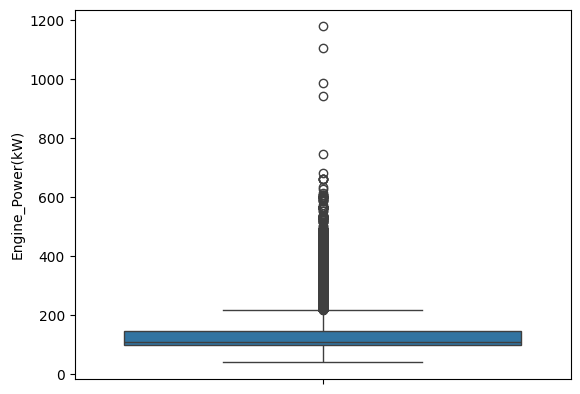

In [93]:
sns.boxplot(df_unique['Engine_Power(kW)'])

### for Mass <--- Nothing to delete

In [94]:
Q1 = df_unique['Mass_in_Running_Order(kg)'].quantile(0.25)
Q3 = df_unique['Mass_in_Running_Order(kg)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_unique[
    (df_unique['Mass_in_Running_Order(kg)'] < lower_bound) |
    (df_unique['Mass_in_Running_Order(kg)'] > upper_bound)
]

print(f"Number of outliers (IQR method): {len(outliers_iqr)}")

Number of outliers (IQR method): 915


In [95]:
df_unique[df_unique['Mass_in_Running_Order(kg)'] < lower_bound]

,Type,Variant,Version,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
67407,SEVENS3,ZA,5,570.0,109.0,petrol,M,658.0,63.0
1347365,SEVENS3,DA,5,700.0,148.0,petrol,M,1999.0,128.0
1449324,SEVEN S3,DA,5,700.0,148.0,petrol,M,1999.0,128.0
2242900,SEVENS3,ZA,5,570.0,119.0,petrol,M,658.0,63.0
2423742,F16,0,2,668.0,142.0,petrol,M,1598.0,77.0
2701355,F16,0,1,658.0,142.0,petrol,M,1598.0,77.0
3296590,SEVENS3,SG,5,700.0,145.0,petrol,M,1596.0,100.0
3486192,SEVEN S3,ZA,5,570.0,109.0,petrol,M,658.0,63.0
5646783,SEVEN S3,D8,5,700.0,206.0,petrol,M,1999.0,177.0
8503193,SEVENSV,D8,5,700.0,191.0,petrol,M,1999.0,176.0


In [96]:
df_unique[df_unique['Mass_in_Running_Order(kg)'] > upper_bound]

,Type,Variant,Version,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
1443,GM,1B4C,B32A5BN,2815.0,292.0,diesel,M,2993.0,183.0
1731,GM,1B4C,B32A5BN,2815.0,313.0,diesel,M,2993.0,183.0
4357,906 AC 35/4X4,K2W62350BXX,QG2CB3A9BEAX,2778.0,322.0,diesel,M,1950.0,140.0
4560,906AC35,NaN,NaN,2788.0,322.0,diesel,M,1951.0,140.0
4927,GM,1B4C,B32A5BN,2815.0,312.0,diesel,M,2993.0,183.0
...,...,...,...,...,...,...,...,...,...
10725224,I 7051 DBM,FIWUFH,M4GL0I43DTN204,3173.0,284.0,diesel,M,2184.0,118.0
10725255,670 SC,LFFJ,K5,3080.0,272.0,diesel,M,2184.0,103.0
10725376,CIF1,NaN,NaN,3048.0,234.0,diesel,M,2184.0,103.0
10725639,FDD,NaN,NaN,3120.0,239.0,diesel,M,1995.0,125.0


## DF After Handling Variable Reduction

In [97]:
df_unique.head(5)

,Type,Variant,Version,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
2,GB,SDLACF1,FM5FM5DF008RT11B174BIAEM10B0,1175.0,129.0,petrol,M,999.0,70.0
3,PJ,ABDSGDX0,NFM5FM5DF0104BI3N1A1A,1122.0,117.0,petrol,M,999.0,59.0
6,3C,ACDTSBX0,FD7FD7GC004SONV4BIVR21AAMI,1588.0,126.0,diesel,M,1968.0,110.0
7,KL,SFDTTCX0,FD7SFD7GC0024BIVL1BAD16A8T,1516.0,124.0,diesel,M,1968.0,110.0
10,NX,ACDPCAX0,NFM6FM6C90134BIVL4N1A1A,1349.0,126.0,petrol,M,1498.0,110.0


In [98]:
df_unique['Fuel_Type'].value_counts(normalize=True)

Fuel_Type
diesel   0.5
petrol   0.5
Name: proportion, dtype: float64

In [99]:
df_unique.shape

(75530, 9)